# Named-feature arms: lexical, affective, TF-IDF

Three sources of evidence about the same transcribed answers, and every
combination of them.

| | lexical | affect | TF-IDF | arm | features (participant) |
|---|---|---|---|---|---|
| 1 | x | | | E10 | 60 |
| 2 | | x | | E11 | 25 |
| 3 | | | x | *E0* | vocabulary only |
| 4 | x | x | | E12 | 85 |
| 5 | x | | x | E13 | 60 + vocabulary |
| 6 | | x | x | E14 | 25 + vocabulary |
| 7 | x | x | x | E15 | 85 + vocabulary |

**Lexical** (`src/lexical_features.py`) counts declared categories: person
and pro-drop, negation and absolutist terms, PHQ-9/GAD-7 symptom subscales,
morphosyntax, lexical richness, spoken-discourse markers.

**Affective** (`src/affective_norms.py`) reads valence, arousal and five
discrete emotions off Spanish norms — ratings native speakers gave to Spanish
words, never translated.

**TF-IDF** is the vocabulary itself with no category imposed on it, over a 1
to 3 token window.

Only the combinations can say whether the sources are complementary or say
the same thing twice, which the paired ablation near the end asks directly.
TF-IDF alone is E0, measured in notebook 01 and not repeated here.

Each arm is fitted at two granularities and two fold counts. Granularity
changes what a training row is — a participant or a single answer — while
the fold count changes only which regressor is selected. Both are logged
separately, so neither overwrites the other.

**Everything reported is on the held-out test participants.** Cross-validation
numbers appear only where labelled and come from training data.

See `PROTOCOL.md` Section 15 for the design decisions behind these arms and
how they deviate from the rest of the study.

In [22]:
%load_ext autoreload
%autoreload 2

import sys
import time
import warnings
from dataclasses import replace
from pathlib import Path

warnings.filterwarnings("ignore")

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src import affective_norms, config, data, encoders, lexical_features, \
    logging_utils, metrics, splits
from src.plotting import plot_confusion_matrix, BAND_LABELS, SCREENING_LABELS
from src.pipeline import TARGETS, \
    LEXICAL_ARM, LEXICAL_ARM_QUESTION, AFFECT_ARM, AFFECT_ARM_QUESTION, \
    LEXICAL_AFFECT_ARM, LEXICAL_AFFECT_ARM_QUESTION, \
    LEXICAL_TFIDF_ARM, LEXICAL_TFIDF_ARM_QUESTION, \
    AFFECT_TFIDF_ARM, AFFECT_TFIDF_ARM_QUESTION, \
    LEXICAL_AFFECT_TFIDF_ARM, LEXICAL_AFFECT_TFIDF_ARM_QUESTION, \
    LEXICAL_TFIDF_NGRAM, arm_models, build_train_frame, compute_lexical_features, \
    encoder_data, expand_to_questions, lexical_results_dir, \
    question_documents, run_encoder, search_label

assert affective_norms.norms_available(), (
    "Stadthagen-Gonzalez norms not found under src/resources/. They are "
    "supplementary material of their papers, not redistributable, and so are "
    "not kept in this repository.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Run configuration

In [23]:
cfg = config.TrainingConfig(
    augmentation=config.AUGMENTATION_NONE,   # config.AUGMENTATION_NONE | config.AUGMENTATION_LLM
    seeds=(42,),
    n_cv_splits=5,
    n_search_iter=0,      # 0 = library defaults; cross-validation still picks the family

    # A kernel model, a tree ensemble and a linear one. Cross-validation
    # still chooses among them, but from a smaller pool than the rest of the
    # study uses, so these rows are not comparable with those. The set is
    # part of the configuration and is logged on every row (PROTOCOL.md 15.2).
    regressors=("SVR", "RandomForest", "RidgeCV"),

    # Stated rather than left to the default: it caps how much of the 1-to-3
    # n-gram window survives, and most of the surviving vocabulary is
    # unigrams and bigrams (PROTOCOL.md 15.3).
    tfidf_max_features=300,
)

# Each arm is fitted once per fold count. The count is part of the selection
# procedure, and with a small training set the two can disagree about which
# regressor wins, so running both says how much a result rests on that choice.
# search_label() writes it into each row's `search` field, so neither run
# supersedes the other.
CV_SPLITS = (5, 10)

PARTICIPANT_ARMS = [LEXICAL_ARM, AFFECT_ARM, LEXICAL_AFFECT_ARM,
                    LEXICAL_TFIDF_ARM, AFFECT_TFIDF_ARM, LEXICAL_AFFECT_TFIDF_ARM]
QUESTION_ARMS = [LEXICAL_ARM_QUESTION, AFFECT_ARM_QUESTION, LEXICAL_AFFECT_ARM_QUESTION,
                 LEXICAL_TFIDF_ARM_QUESTION, AFFECT_TFIDF_ARM_QUESTION,
                 LEXICAL_AFFECT_TFIDF_ARM_QUESTION]
NOTEBOOK_ARMS = PARTICIPANT_ARMS + QUESTION_ARMS
ARM_MODELS = {**arm_models(cfg), **arm_models(cfg, question_level=True)}

print("models:", cfg.regressors, " folds:", CV_SPLITS)
print("n-gram window:", LEXICAL_TFIDF_NGRAM, " cap:", cfg.tfidf_max_features)
for name in ("lexical", "affect", "lexical-affect"):
    spec = lexical_features.feature_set(name)
    print(f"  {name:15s} {spec.version:22s} "
          f"{len(lexical_features.answer_features(name)):3d} per answer, "
          f"{len(lexical_features.participant_features(name)):3d} per participant")
cfg

models: ('SVR', 'RandomForest', 'RidgeCV')  folds: (5, 10)
n-gram window: (1, 3)  cap: 300
  lexical         lexical-v1              51 per answer,  60 per participant
  affect          affect-v1               21 per answer,  25 per participant
  lexical-affect  lexical-affect-v1       72 per answer,  85 per participant


TrainingConfig(augmentation='no_augmentation', seeds=(42,), n_cv_splits=5, n_search_iter=0, regressors=('SVR', 'RandomForest', 'RidgeCV'), beto_model='dccuchile/bert-base-spanish-wwm-cased', sentence_transformer_model='intfloat/multilingual-e5-small', mental_es_model='ELiRF/RoBERTa-es-mental-large', max_tokens=512, chunk_stride=256, tfidf_max_features=300, tfidf_ngram_range=(1, 2), tfidf_min_df=3, tfidf_max_df=0.9, tfidf_lemmatize=True, tfidf_normalize_numbers=True)

In [24]:
df = data.load_dataset()
train_ids, test_ids = splits.train_test_participants(df)
train_frame, aug_groups = build_train_frame(df, train_ids, test_ids, cfg)
test_frame = df.loc[test_ids]
N_TEST = len(test_frame)

# With augmentation the group is the original participant, so a paraphrase
# never lands in a different fold than the answer it came from.
group_col = "original_participant" if aug_groups is not None else None
q_train = expand_to_questions(train_frame, group_col=group_col)
q_test = expand_to_questions(test_frame)
q_groups = q_train["group"].to_numpy()
q_test_groups = q_test["participant"].to_numpy()

print(f"train: {len(train_frame)} participants -> {len(q_train)} question rows")
print(f"test:  {N_TEST} held-out participants -> {len(q_test)} question rows")

train: 110 participants -> 376 question rows
test:  48 held-out participants -> 168 question rows


### Features

These arms write to `results/lexical/<augmentation>/<granularity>/`, their own
family in the results tree.

Each feature set is computed once for train and test together and cached,
keyed by the set's version so a stale matrix is rejected rather than reused.
The TF-IDF arms reuse their base arm's cached matrix, so E13 carries exactly
E10's columns and the contrast between them is the vectorizer alone.

The vectorizer is not cached: it is fitted inside each cross-validation fold,
so no fold's vocabulary is built from the rows it is scored on.

In [25]:
# results/lexical/<augmentation>/<granularity>/. Its own family: these arms
# are procedurally frozen arms, but the named-feature study is kept as one
# tree rather than interleaved with the encoder comparison.
participant_dir = lexical_results_dir(cfg)
question_dir = lexical_results_dir(cfg, question_level=True)
print("writing to:", participant_dir.parent)

combined = pd.concat([train_frame[config.QUESTIONS], test_frame[config.QUESTIONS]])
q_combined = pd.concat([q_train[["text"]], q_test[["text"]]])

t0 = time.time()
participant_features = compute_lexical_features(combined, participant_dir)
question_features = compute_lexical_features(q_combined, question_dir, question_level=True)

# TF-IDF input, normalized as E0 normalizes it: numbers replaced, then lemmatized.
docs_all = encoders.participant_documents(combined, cfg)
q_docs_all = question_documents(q_combined, cfg)
print(f"extracted in {time.time() - t0:.0f}s")
for name, matrix in {**participant_features, **question_features}.items():
    print(f"{name}: {matrix.shape}")

writing to: C:\IA\Multimodal-Modeling\text_experiment\results\lexical\no_augmentation
extracted in 88s
E10_LEXICAL: (158, 60)
E11_AFFECT: (158, 25)
E12_LEXICAL_AFFECT: (158, 85)
E10_LEXICAL_QUESTION: (544, 51)
E11_AFFECT_QUESTION: (544, 21)
E12_LEXICAL_AFFECT_QUESTION: (544, 72)


In [26]:
def report_encoder(encoder_name, run_rows, granularity, run_cfg=None):
    run_cfg = run_cfg or cfg
    runs = pd.DataFrame(run_rows)
    print(f"[TEST] {encoder_name} ({run_cfg.n_cv_splits}-fold): metrics on the "
          f"{N_TEST} held-out participants")
    display(runs.pivot(index="seed", columns="target", values=["rmse", "mae", "r2"]).round(3))

    # load_trials defaults to FAMILY_FROZEN; these arms log under their own.
    trials = logging_utils.load_trials(run_cfg.augmentation,
                                       family=config.FAMILY_LEXICAL,
                                       granularity=granularity)
    trials = trials[(trials["encoder"] == encoder_name)
                    & (trials["search"] == search_label(run_cfg))]
    # The trial log is append-only and keeps every run's candidates. A previous
    # run under the full nine-model set still has rows here that no later run
    # supersedes, because their model names are ones the current set never
    # emits. Restricting the view keeps this a report of the run rather than
    # of the file's history.
    if run_cfg.regressors:
        trials = trials[trials["model_name"].isin(run_cfg.regressors)]
    for target in TARGETS:
        print(f"[CROSS-VALIDATION on training data] RMSE per candidate ({target}). "
              f"This is what model selection used; it is not a test score.")
        display(trials[trials["target"] == target].pivot(
            index="model_name", columns="seed", values="cv_rmse").round(3))

    fig, axes = plt.subplots(2, 2, figsize=(9, 8))
    for i, target in enumerate(TARGETS):
        best_row = runs[runs["target"] == target].iloc[0]
        seed = int(best_row["seed"])
        plot_confusion_matrix(axes[i, 0], best_row["band_confusion_matrix"], BAND_LABELS,
                              f"{target} severity bands (seed={seed})")
        plot_confusion_matrix(axes[i, 1], best_row["screening_confusion_matrix"],
                              SCREENING_LABELS, f"{target} screening (seed={seed})")
    plt.suptitle(f"[TEST] {encoder_name} ({run_cfg.n_cv_splits}-fold): confusion matrices")
    plt.tight_layout()
    plt.show()


def train_and_report(arm, granularity=config.GRANULARITY_PARTICIPANT, report=True):
    """Fits one arm at one granularity, once per fold count, and logs each.

    Both granularities go through the same function so an arm cannot end up
    fitted one way at participant level and another way per question. Question
    level trains on one row per answer and averages predictions back per
    participant before any metric, so every arm is scored on the same 48
    people whatever it trained on.

    The fold count changes only how the regressor is chosen: the hold-out
    split, the features and the candidate models are identical across the
    two, so the pair reads as how much a result rests on that choice.
    """
    if granularity == config.GRANULARITY_PARTICIPANT:
        base, feats, docs = combined, participant_features, docs_all
        fit_frame, eval_frame, groups, test_groups = \
            train_frame, test_frame, aug_groups, None
    else:
        base, feats, docs = q_combined, question_features, q_docs_all
        fit_frame, eval_frame, groups, test_groups = \
            q_train, q_test, q_groups, q_test_groups

    all_rows = []
    for n_splits in CV_SPLITS:
        run_cfg = replace(cfg, n_cv_splits=n_splits)
        X, preprocessor = encoder_data(arm, base, docs, feats, run_cfg)
        t0 = time.time()
        rows = run_encoder(arm, X.loc[fit_frame.index], X.loc[eval_frame.index],
                           preprocessor, fit_frame, eval_frame, groups, run_cfg,
                           test_groups=test_groups, notebook="08",
                           encoder_model=ARM_MODELS[arm])
        print(f"{arm}: {X.shape[1]} columns, {n_splits}-fold, "
              f"{(time.time() - t0) / 60:.1f} min")
        if report:
            report_encoder(arm, rows, granularity, run_cfg)
        all_rows += rows
    return all_rows

## Stage 1: lexical alone (E10)

Counts of declared categories: person and pro-drop marking, negation and
absolutist terms, PHQ-9/GAD-7 symptom subscales, morphosyntax, lexical
richness and spoken-discourse markers.

E10_LEXICAL seed=42 target=PHQ9 best=SVR rmse=5.833 r2=-0.127 (2.7s)
E10_LEXICAL seed=42 target=GAD7 best=RandomForest rmse=4.831 r2=0.078 (2.9s)
E10_LEXICAL: 60 columns, 5-fold, 0.1 min
[TEST] E10_LEXICAL (5-fold): metrics on the 48 held-out participants


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.831  5.833  3.998  4.895  0.078 -0.127

[CROSS-VALIDATION on training data] RMSE per candidate (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,5.920
RidgeCV,5.747
SVR,5.733


[CROSS-VALIDATION on training data] RMSE per candidate (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,4.738
RidgeCV,4.847
SVR,4.754


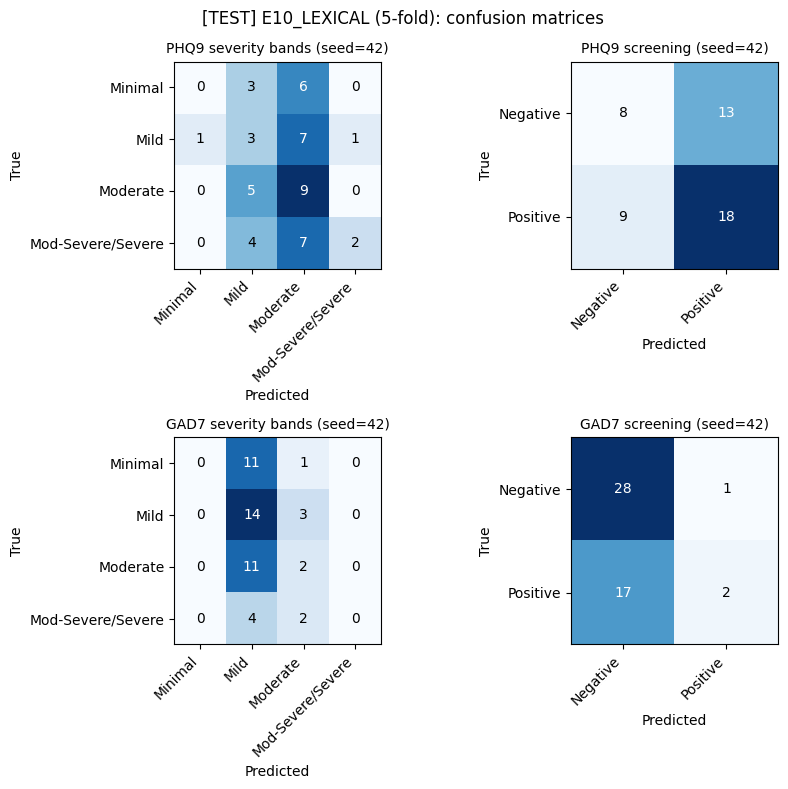

E10_LEXICAL seed=42 target=PHQ9 best=SVR rmse=5.833 r2=-0.127 (5.1s)
E10_LEXICAL seed=42 target=GAD7 best=SVR rmse=5.186 r2=-0.062 (5.1s)
E10_LEXICAL: 60 columns, 10-fold, 0.2 min
[TEST] E10_LEXICAL (10-fold): metrics on the 48 held-out participants


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      5.186  5.833  4.327  4.895 -0.062 -0.127

[CROSS-VALIDATION on training data] RMSE per candidate (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,5.898
RidgeCV,5.825
SVR,5.773


[CROSS-VALIDATION on training data] RMSE per candidate (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,4.801
RidgeCV,5.067
SVR,4.647


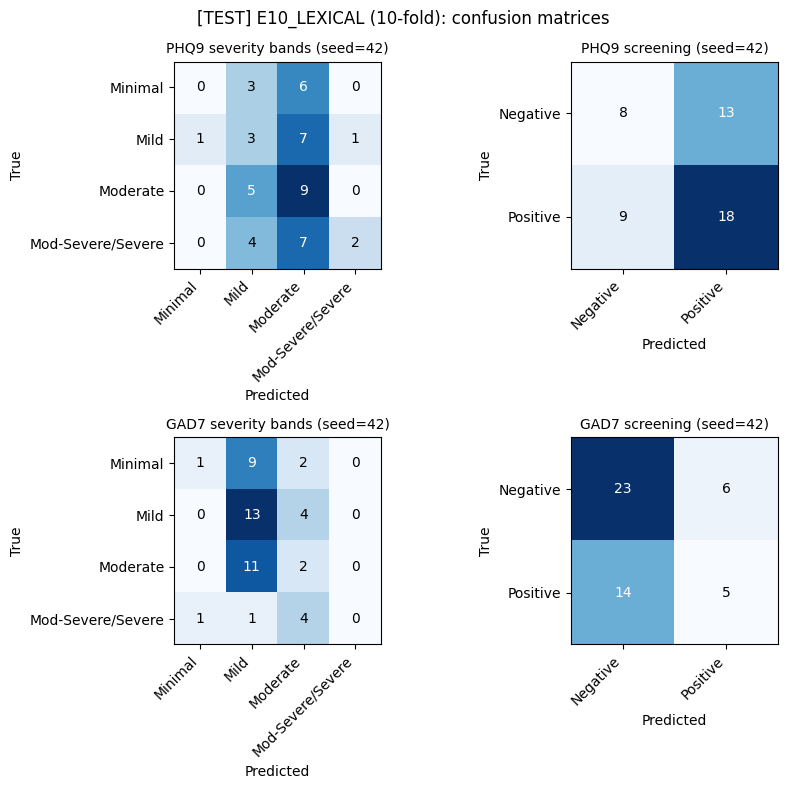

In [27]:
_ = train_and_report(LEXICAL_ARM, config.GRANULARITY_PARTICIPANT)

E10_LEXICAL_QUESTION seed=42 target=PHQ9 best=RandomForest rmse=5.338 r2=0.056 (3.1s)
E10_LEXICAL_QUESTION seed=42 target=GAD7 best=RidgeCV rmse=4.868 r2=0.064 (3.1s)
E10_LEXICAL_QUESTION: 51 columns, 5-fold, 0.1 min
[TEST] E10_LEXICAL_QUESTION (5-fold): metrics on the 48 held-out participants


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.868  5.338  4.058  4.348  0.064  0.056

[CROSS-VALIDATION on training data] RMSE per candidate (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,6.012
RidgeCV,6.107
SVR,6.097


[CROSS-VALIDATION on training data] RMSE per candidate (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,5.017
RidgeCV,5.006
SVR,5.019


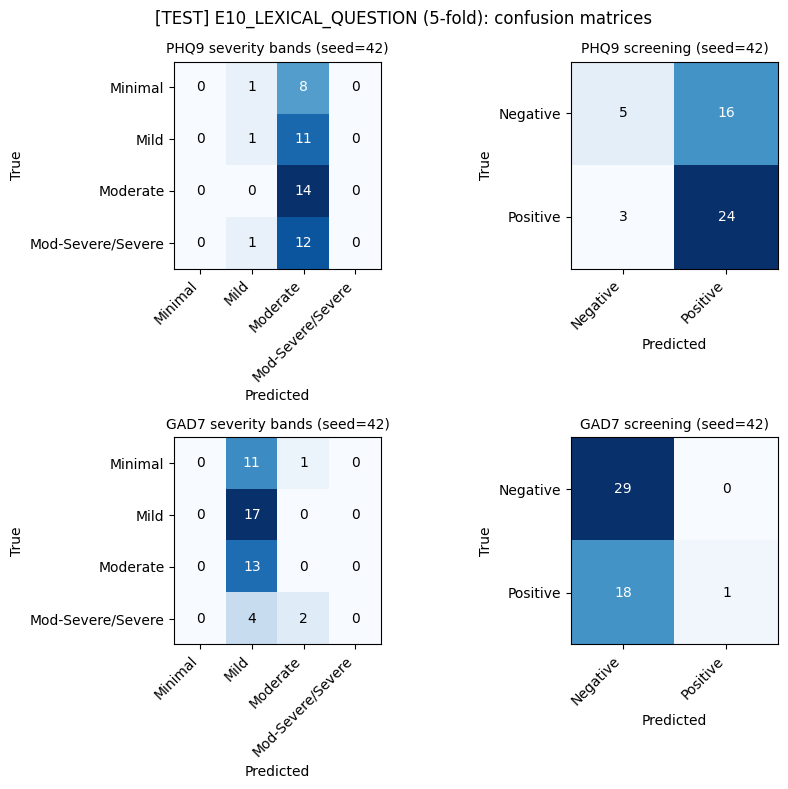

E10_LEXICAL_QUESTION seed=42 target=PHQ9 best=RandomForest rmse=5.338 r2=0.056 (6.2s)
E10_LEXICAL_QUESTION seed=42 target=GAD7 best=SVR rmse=4.997 r2=0.013 (6.0s)
E10_LEXICAL_QUESTION: 51 columns, 10-fold, 0.2 min
[TEST] E10_LEXICAL_QUESTION (10-fold): metrics on the 48 held-out participants


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.997  5.338  4.231  4.348  0.013  0.056

[CROSS-VALIDATION on training data] RMSE per candidate (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,5.844
RidgeCV,6.013
SVR,5.971


[CROSS-VALIDATION on training data] RMSE per candidate (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,4.978
RidgeCV,4.949
SVR,4.914


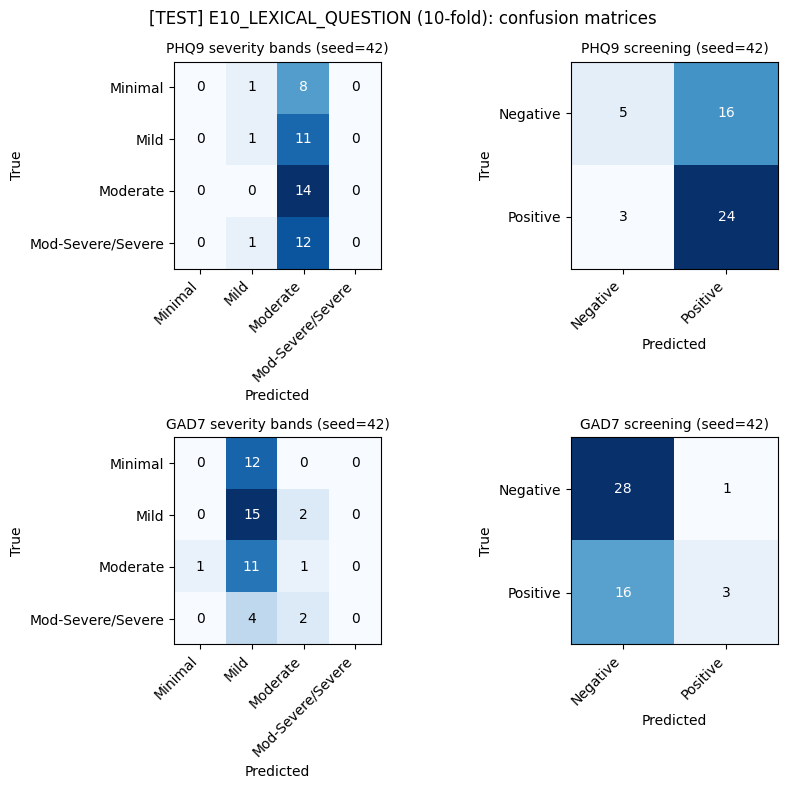

In [28]:
_ = train_and_report(LEXICAL_ARM_QUESTION, config.GRANULARITY_QUESTION)

## Stage 2: affective alone (E11)

Valence, arousal and five discrete emotions, read off norms that native
Spanish speakers gave to Spanish words. Where the lexical set counts which
categories appear, this one measures how the words used are rated.

E11_AFFECT seed=42 target=PHQ9 best=RidgeCV rmse=5.427 r2=0.025 (2.6s)
E11_AFFECT seed=42 target=GAD7 best=RidgeCV rmse=5.087 r2=-0.022 (3.1s)
E11_AFFECT: 25 columns, 5-fold, 0.1 min
[TEST] E11_AFFECT (5-fold): metrics on the 48 held-out participants


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      5.087  5.427  4.155  4.477 -0.022  0.025

[CROSS-VALIDATION on training data] RMSE per candidate (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,5.905
RidgeCV,5.853
SVR,6.442


[CROSS-VALIDATION on training data] RMSE per candidate (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,4.787
RidgeCV,4.655
SVR,5.210


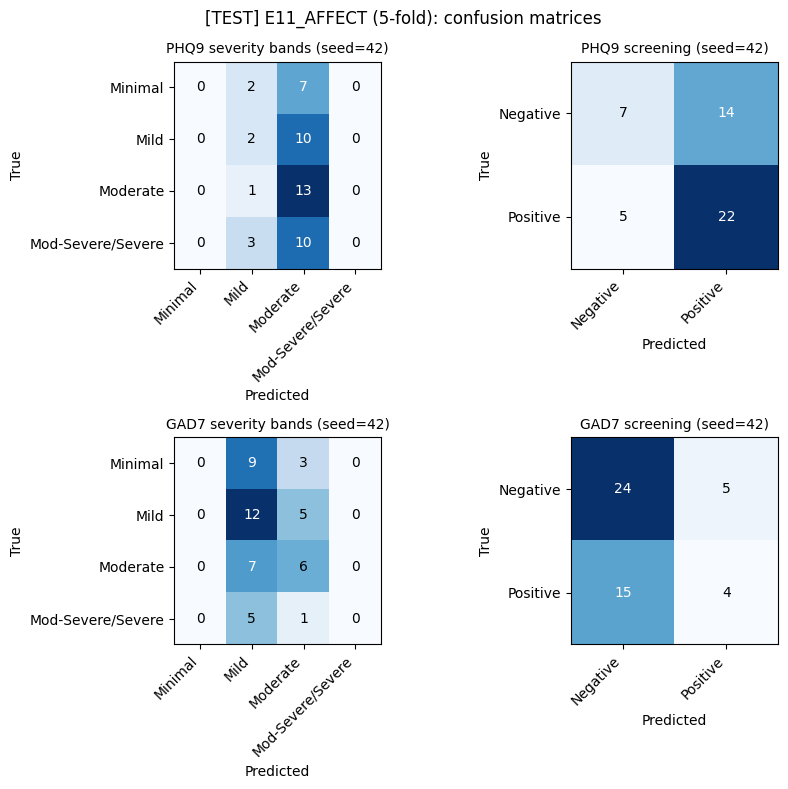

E11_AFFECT seed=42 target=PHQ9 best=RidgeCV rmse=5.427 r2=0.025 (2.6s)
E11_AFFECT seed=42 target=GAD7 best=RidgeCV rmse=5.087 r2=-0.022 (2.5s)
E11_AFFECT: 25 columns, 10-fold, 0.1 min
[TEST] E11_AFFECT (10-fold): metrics on the 48 held-out participants


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      5.087  5.427  4.155  4.477 -0.022  0.025

[CROSS-VALIDATION on training data] RMSE per candidate (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,5.812
RidgeCV,5.778
SVR,6.246


[CROSS-VALIDATION on training data] RMSE per candidate (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,4.792
RidgeCV,4.610
SVR,4.916


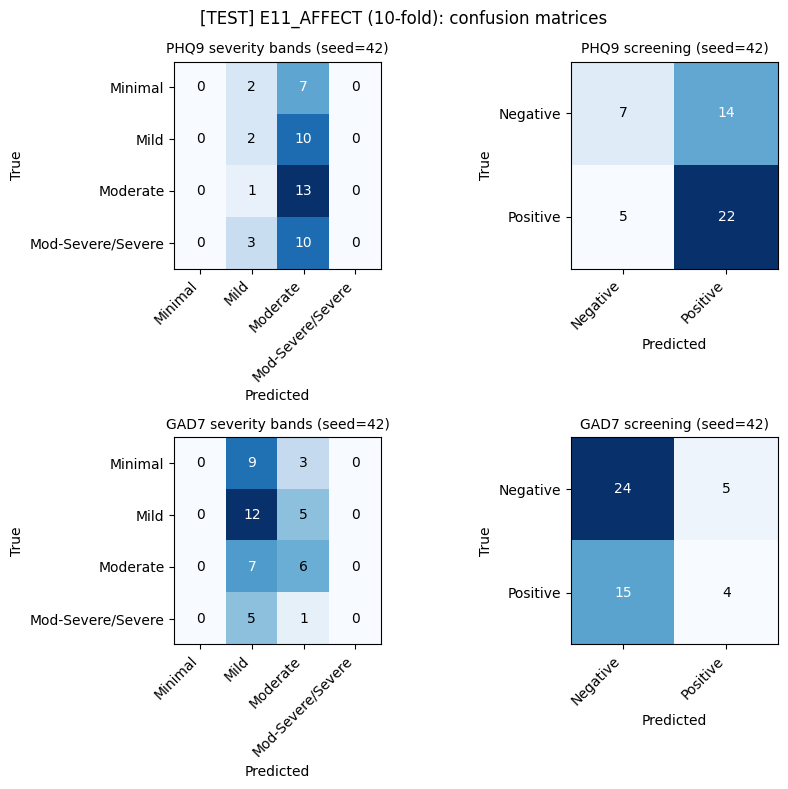

In [29]:
_ = train_and_report(AFFECT_ARM, config.GRANULARITY_PARTICIPANT)

E11_AFFECT_QUESTION seed=42 target=PHQ9 best=RidgeCV rmse=5.420 r2=0.027 (1.4s)
E11_AFFECT_QUESTION seed=42 target=GAD7 best=RidgeCV rmse=4.984 r2=0.019 (1.4s)
E11_AFFECT_QUESTION: 21 columns, 5-fold, 0.0 min
[TEST] E11_AFFECT_QUESTION (5-fold): metrics on the 48 held-out participants


rmse          mae            r2       
target   GAD7  PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                           
42      4.984  5.42  4.117  4.447  0.019  0.027

[CROSS-VALIDATION on training data] RMSE per candidate (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,5.941
RidgeCV,5.918
SVR,6.311


[CROSS-VALIDATION on training data] RMSE per candidate (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,4.863
RidgeCV,4.860
SVR,5.276


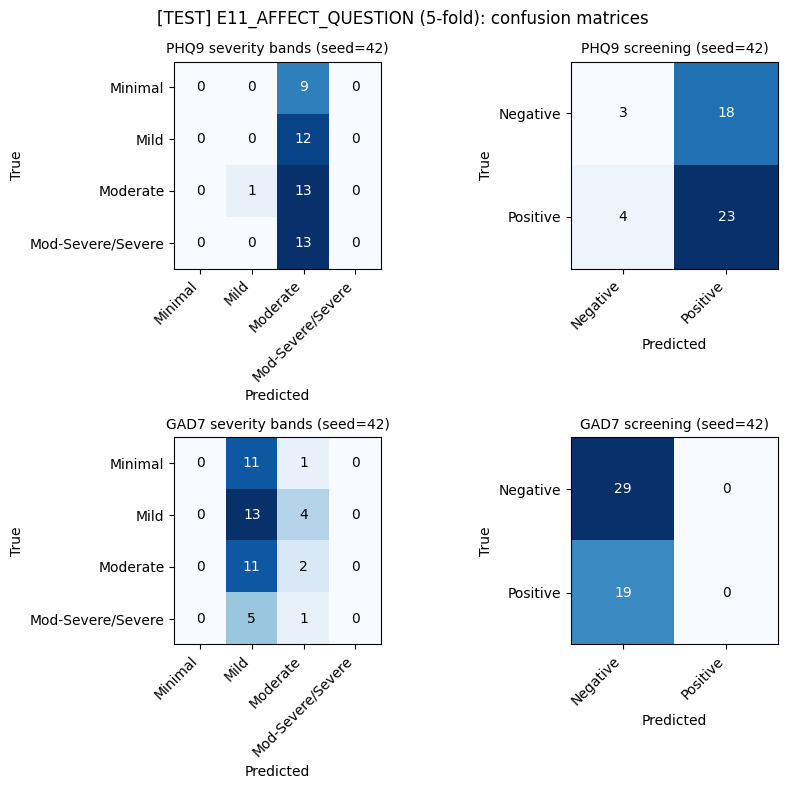

E11_AFFECT_QUESTION seed=42 target=PHQ9 best=RidgeCV rmse=5.420 r2=0.027 (2.5s)
E11_AFFECT_QUESTION seed=42 target=GAD7 best=RandomForest rmse=4.966 r2=0.026 (2.6s)
E11_AFFECT_QUESTION: 21 columns, 10-fold, 0.1 min
[TEST] E11_AFFECT_QUESTION (10-fold): metrics on the 48 held-out participants


rmse          mae            r2       
target   GAD7  PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                           
42      4.966  5.42  4.112  4.447  0.026  0.027

[CROSS-VALIDATION on training data] RMSE per candidate (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,5.847
RidgeCV,5.776
SVR,6.230


[CROSS-VALIDATION on training data] RMSE per candidate (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,4.792
RidgeCV,4.794
SVR,5.173


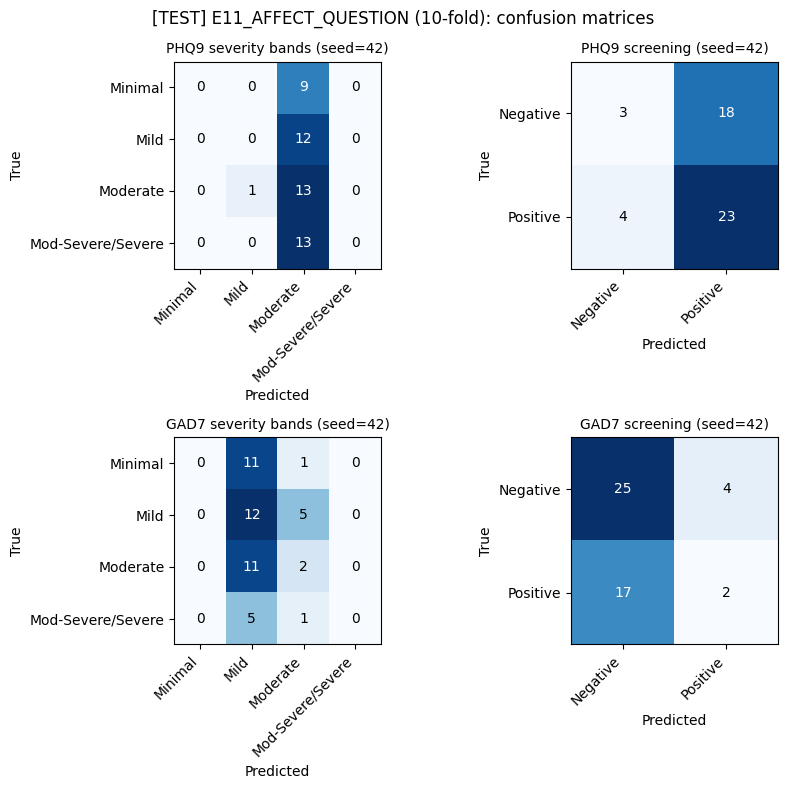

In [30]:
_ = train_and_report(AFFECT_ARM_QUESTION, config.GRANULARITY_QUESTION)

## Stage 3: lexical and affective (E12)

Both named-feature sets together. Read against E10 and E11 rather than on
its own: the question is whether the two sources add to each other. It is also
the widest matrix here, so dimensionality is a competing explanation for any
result it gives at participant level.

E12_LEXICAL_AFFECT seed=42 target=PHQ9 best=SVR rmse=5.385 r2=0.039 (1.5s)
E12_LEXICAL_AFFECT seed=42 target=GAD7 best=RandomForest rmse=4.885 r2=0.057 (1.3s)
E12_LEXICAL_AFFECT: 85 columns, 5-fold, 0.0 min
[TEST] E12_LEXICAL_AFFECT (5-fold): metrics on the 48 held-out participants


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.885  5.385  3.967  4.362  0.057  0.039

[CROSS-VALIDATION on training data] RMSE per candidate (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,5.761
RidgeCV,5.964
SVR,5.712


[CROSS-VALIDATION on training data] RMSE per candidate (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,4.686
RidgeCV,5.134
SVR,4.744


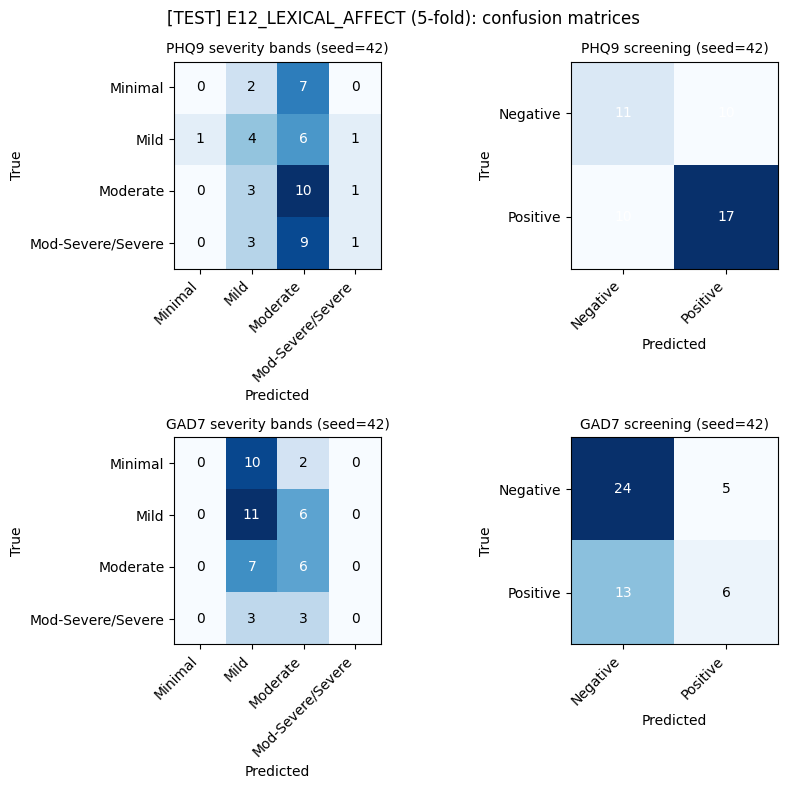

E12_LEXICAL_AFFECT seed=42 target=PHQ9 best=RandomForest rmse=5.166 r2=0.116 (2.4s)
E12_LEXICAL_AFFECT seed=42 target=GAD7 best=SVR rmse=4.995 r2=0.014 (4.4s)
E12_LEXICAL_AFFECT: 85 columns, 10-fold, 0.1 min
[TEST] E12_LEXICAL_AFFECT (10-fold): metrics on the 48 held-out participants


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.995  5.166  3.991  4.245  0.014  0.116

[CROSS-VALIDATION on training data] RMSE per candidate (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,5.743
RidgeCV,5.995
SVR,5.751


[CROSS-VALIDATION on training data] RMSE per candidate (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,4.694
RidgeCV,5.081
SVR,4.615


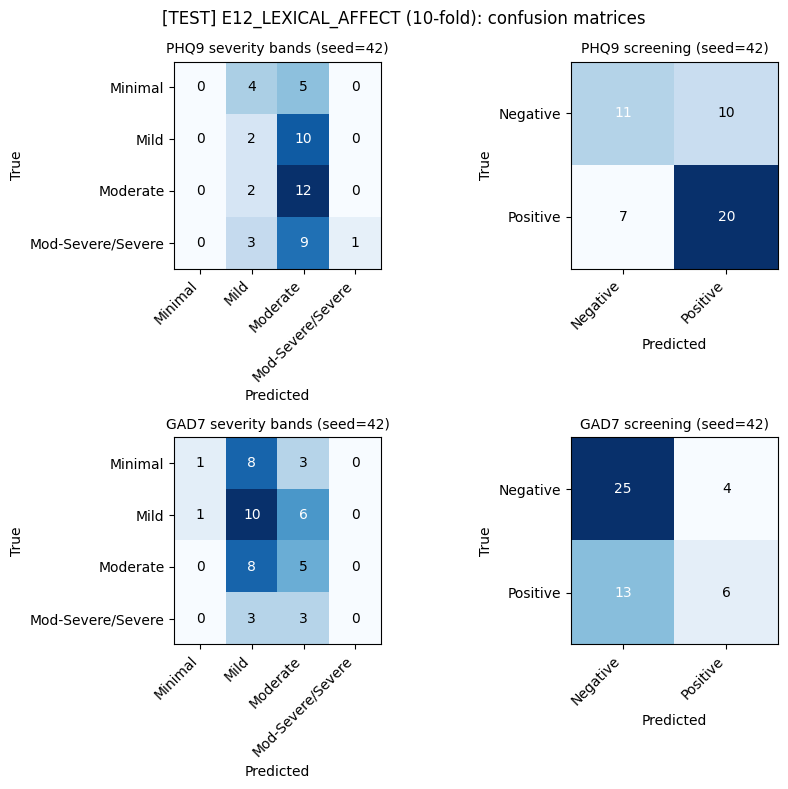

In [31]:
_ = train_and_report(LEXICAL_AFFECT_ARM, config.GRANULARITY_PARTICIPANT)

E12_LEXICAL_AFFECT_QUESTION seed=42 target=PHQ9 best=SVR rmse=5.461 r2=0.012 (3.1s)
E12_LEXICAL_AFFECT_QUESTION seed=42 target=GAD7 best=RidgeCV rmse=4.847 r2=0.072 (1.6s)
E12_LEXICAL_AFFECT_QUESTION: 72 columns, 5-fold, 0.1 min
[TEST] E12_LEXICAL_AFFECT_QUESTION (5-fold): metrics on the 48 held-out participants


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.847  5.461  4.021  4.585  0.072  0.012

[CROSS-VALIDATION on training data] RMSE per candidate (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,5.902
RidgeCV,5.931
SVR,5.871


[CROSS-VALIDATION on training data] RMSE per candidate (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,4.877
RidgeCV,4.852
SVR,4.962


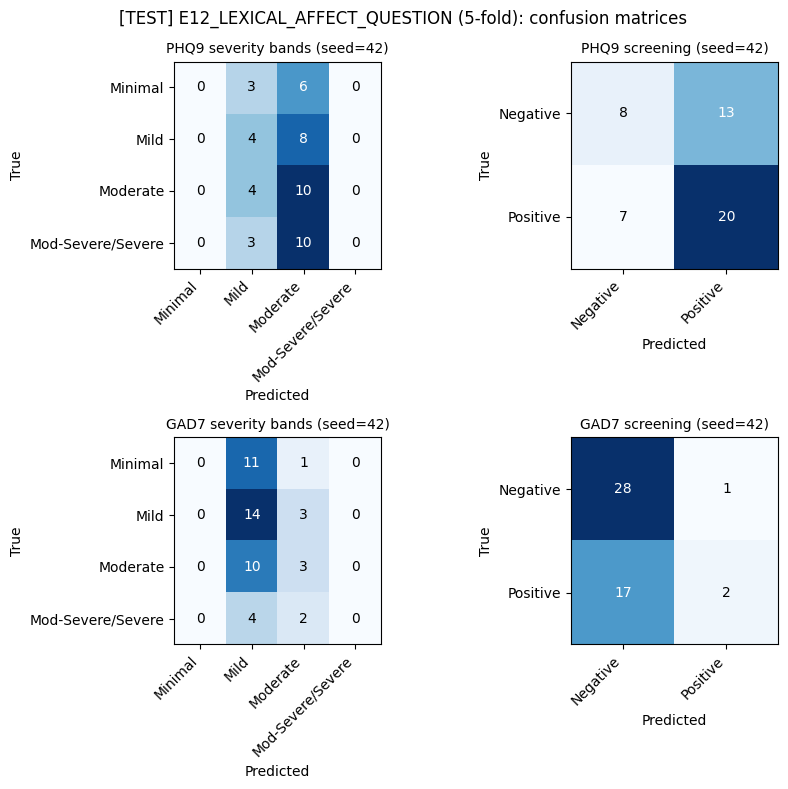

E12_LEXICAL_AFFECT_QUESTION seed=42 target=PHQ9 best=RandomForest rmse=5.216 r2=0.099 (2.6s)
E12_LEXICAL_AFFECT_QUESTION seed=42 target=GAD7 best=RidgeCV rmse=4.847 r2=0.072 (2.6s)
E12_LEXICAL_AFFECT_QUESTION: 72 columns, 10-fold, 0.1 min
[TEST] E12_LEXICAL_AFFECT_QUESTION (10-fold): metrics on the 48 held-out participants


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.847  5.216  4.021  4.294  0.072  0.099

[CROSS-VALIDATION on training data] RMSE per candidate (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,5.763
RidgeCV,5.845
SVR,5.766


[CROSS-VALIDATION on training data] RMSE per candidate (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,4.798
RidgeCV,4.790
SVR,4.856


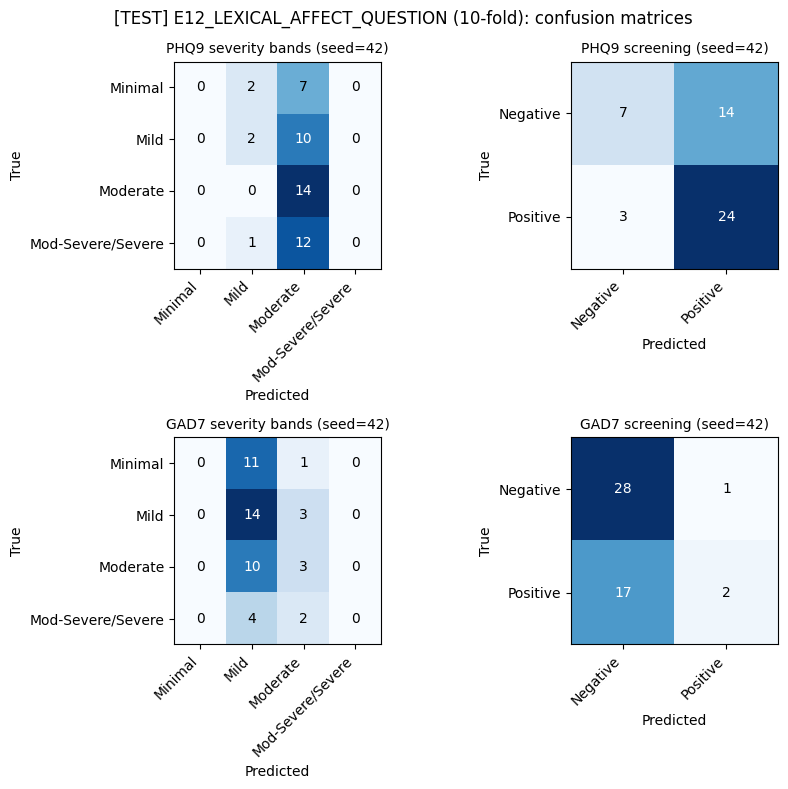

In [32]:
_ = train_and_report(LEXICAL_AFFECT_ARM_QUESTION, config.GRANULARITY_QUESTION)

## Stage 4: lexical and TF-IDF (E13)

The lexical columns plus the vocabulary itself. A phrase is what a category
counter structurally cannot see: "no me siento bien" is a negated state spread
across three tokens, and no single count encodes it.

E13_LEXICAL_TFIDF seed=42 target=PHQ9 best=SVR rmse=5.813 r2=-0.119 (3.2s)
E13_LEXICAL_TFIDF seed=42 target=GAD7 best=RidgeCV rmse=5.191 r2=-0.064 (3.2s)
E13_LEXICAL_TFIDF: 61 columns, 5-fold, 0.1 min
[TEST] E13_LEXICAL_TFIDF (5-fold): metrics on the 48 held-out participants


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      5.191  5.813  4.255  4.875 -0.064 -0.119

[CROSS-VALIDATION on training data] RMSE per candidate (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,5.848
RidgeCV,5.866
SVR,5.728


[CROSS-VALIDATION on training data] RMSE per candidate (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,4.733
RidgeCV,4.730
SVR,4.754


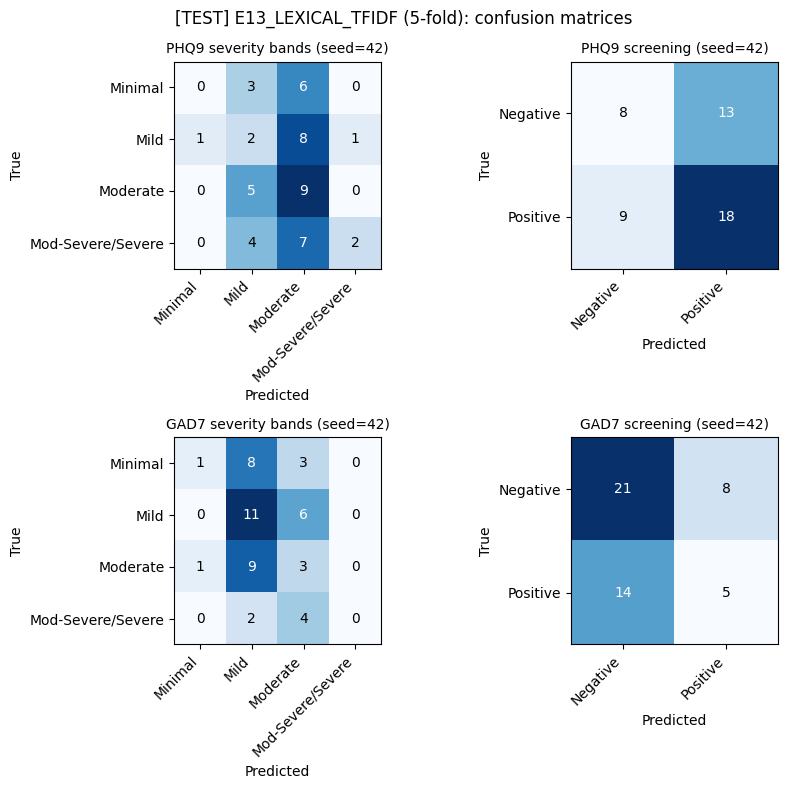

E13_LEXICAL_TFIDF seed=42 target=PHQ9 best=RandomForest rmse=5.318 r2=0.063 (9.8s)
E13_LEXICAL_TFIDF seed=42 target=GAD7 best=SVR rmse=5.171 r2=-0.056 (11.1s)
E13_LEXICAL_TFIDF: 61 columns, 10-fold, 0.3 min
[TEST] E13_LEXICAL_TFIDF (10-fold): metrics on the 48 held-out participants


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      5.171  5.318  4.318  4.378 -0.056  0.063

[CROSS-VALIDATION on training data] RMSE per candidate (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,5.762
RidgeCV,5.826
SVR,5.764


[CROSS-VALIDATION on training data] RMSE per candidate (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,4.725
RidgeCV,5.071
SVR,4.645


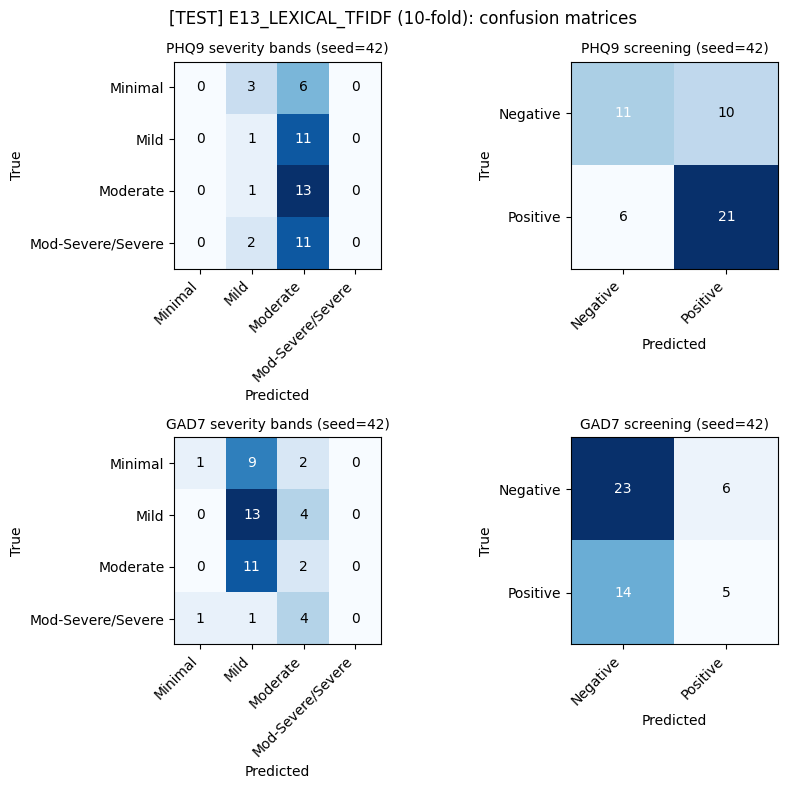

In [33]:
_ = train_and_report(LEXICAL_TFIDF_ARM, config.GRANULARITY_PARTICIPANT)

E13_LEXICAL_TFIDF_QUESTION seed=42 target=PHQ9 best=RandomForest rmse=5.197 r2=0.105 (7.1s)
E13_LEXICAL_TFIDF_QUESTION seed=42 target=GAD7 best=RandomForest rmse=4.816 r2=0.084 (7.2s)
E13_LEXICAL_TFIDF_QUESTION: 52 columns, 5-fold, 0.2 min
[TEST] E13_LEXICAL_TFIDF_QUESTION (5-fold): metrics on the 48 held-out participants


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.816  5.197  4.005  4.197  0.084  0.105

[CROSS-VALIDATION on training data] RMSE per candidate (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,5.859
RidgeCV,6.099
SVR,6.063


[CROSS-VALIDATION on training data] RMSE per candidate (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,4.881
RidgeCV,5.010
SVR,4.998


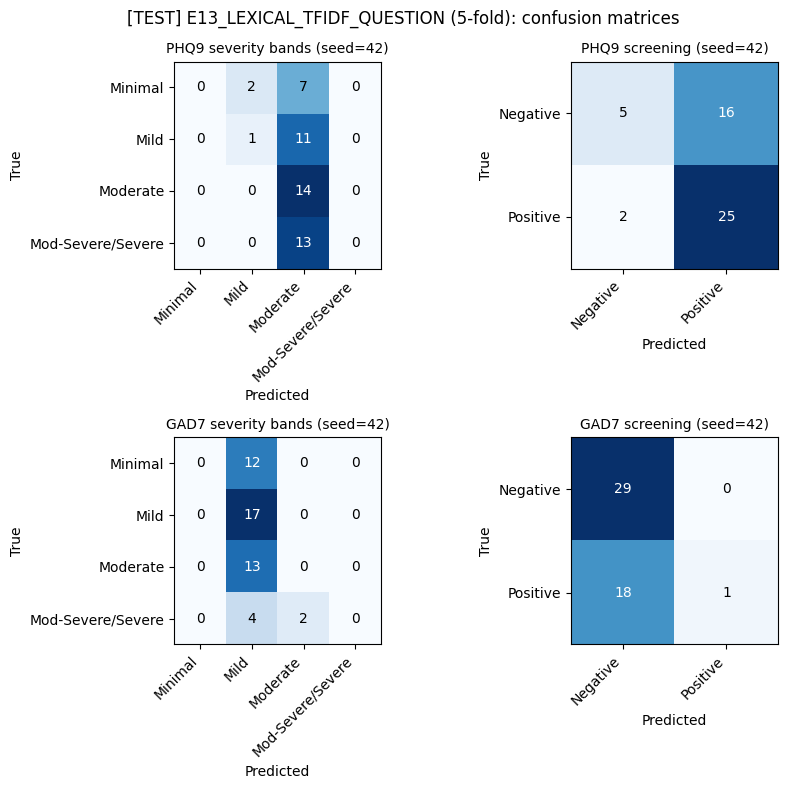

E13_LEXICAL_TFIDF_QUESTION seed=42 target=PHQ9 best=RandomForest rmse=5.197 r2=0.105 (12.6s)
E13_LEXICAL_TFIDF_QUESTION seed=42 target=GAD7 best=RandomForest rmse=4.816 r2=0.084 (13.2s)
E13_LEXICAL_TFIDF_QUESTION: 52 columns, 10-fold, 0.4 min
[TEST] E13_LEXICAL_TFIDF_QUESTION (10-fold): metrics on the 48 held-out participants


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.816  5.197  4.005  4.197  0.084  0.105

[CROSS-VALIDATION on training data] RMSE per candidate (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,5.716
RidgeCV,6.012
SVR,5.942


[CROSS-VALIDATION on training data] RMSE per candidate (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,4.825
RidgeCV,4.945
SVR,4.891


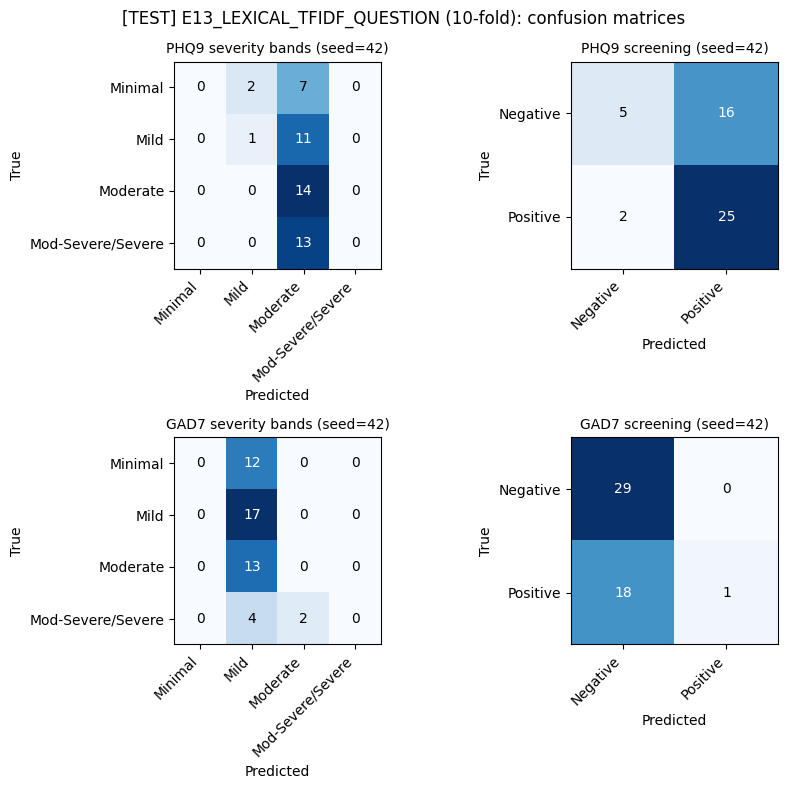

In [34]:
_ = train_and_report(LEXICAL_TFIDF_ARM_QUESTION, config.GRANULARITY_QUESTION)

## Stage 5: affective and TF-IDF (E14)

The affective columns plus the vocabulary. The affective set says how the
words used are rated but nothing about which words they were, so this is where
the vocabulary has the most to add.

E14_AFFECT_TFIDF seed=42 target=PHQ9 best=RandomForest rmse=5.380 r2=0.041 (6.0s)
E14_AFFECT_TFIDF seed=42 target=GAD7 best=RandomForest rmse=4.955 r2=0.030 (6.1s)
E14_AFFECT_TFIDF: 26 columns, 5-fold, 0.2 min
[TEST] E14_AFFECT_TFIDF (5-fold): metrics on the 48 held-out participants


rmse          mae           r2       
target   GAD7  PHQ9   GAD7   PHQ9  GAD7   PHQ9
seed                                          
42      4.955  5.38  4.087  4.389  0.03  0.041

[CROSS-VALIDATION on training data] RMSE per candidate (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,5.669
RidgeCV,5.890
SVR,6.387


[CROSS-VALIDATION on training data] RMSE per candidate (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,4.636
RidgeCV,4.655
SVR,5.182


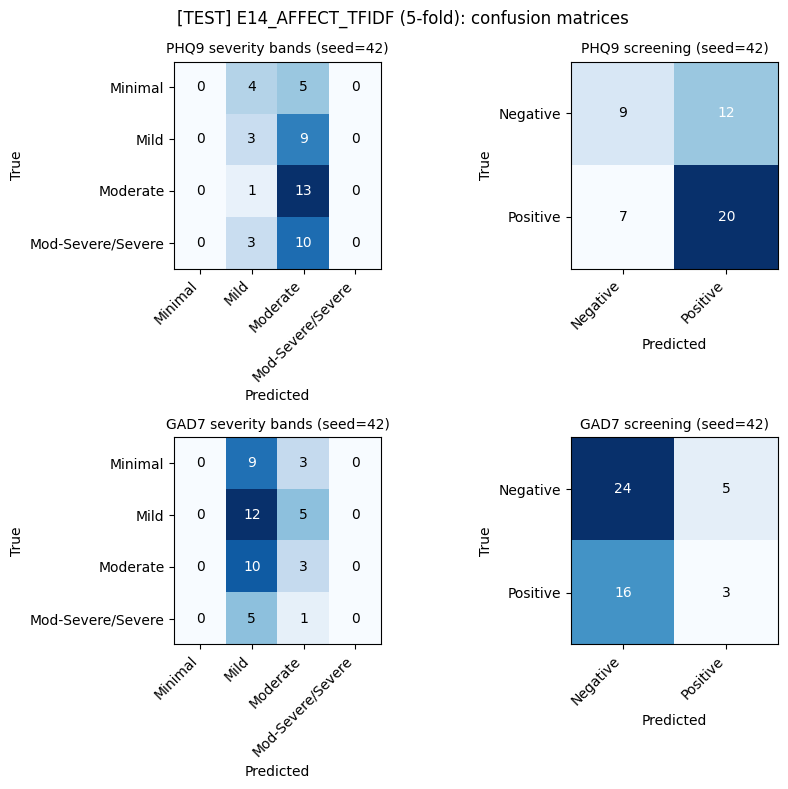

E14_AFFECT_TFIDF seed=42 target=PHQ9 best=RandomForest rmse=5.380 r2=0.041 (10.9s)
E14_AFFECT_TFIDF seed=42 target=GAD7 best=RandomForest rmse=4.955 r2=0.030 (11.0s)
E14_AFFECT_TFIDF: 26 columns, 10-fold, 0.4 min
[TEST] E14_AFFECT_TFIDF (10-fold): metrics on the 48 held-out participants


rmse          mae           r2       
target   GAD7  PHQ9   GAD7   PHQ9  GAD7   PHQ9
seed                                          
42      4.955  5.38  4.087  4.389  0.03  0.041

[CROSS-VALIDATION on training data] RMSE per candidate (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,5.711
RidgeCV,5.777
SVR,6.200


[CROSS-VALIDATION on training data] RMSE per candidate (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,4.590
RidgeCV,4.609
SVR,4.897


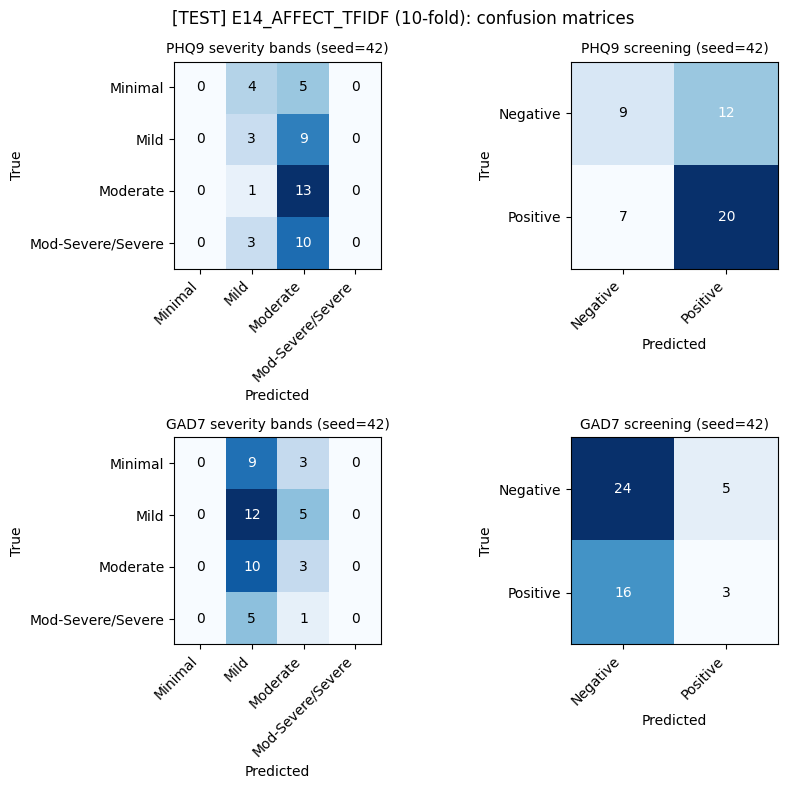

In [35]:
_ = train_and_report(AFFECT_TFIDF_ARM, config.GRANULARITY_PARTICIPANT)

E14_AFFECT_TFIDF_QUESTION seed=42 target=PHQ9 best=RandomForest rmse=5.292 r2=0.072 (7.2s)
E14_AFFECT_TFIDF_QUESTION seed=42 target=GAD7 best=RandomForest rmse=4.848 r2=0.071 (7.2s)
E14_AFFECT_TFIDF_QUESTION: 22 columns, 5-fold, 0.2 min
[TEST] E14_AFFECT_TFIDF_QUESTION (5-fold): metrics on the 48 held-out participants


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.848  5.292  3.982  4.307  0.071  0.072

[CROSS-VALIDATION on training data] RMSE per candidate (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,5.751
RidgeCV,6.161
SVR,6.247


[CROSS-VALIDATION on training data] RMSE per candidate (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,4.749
RidgeCV,4.990
SVR,5.205


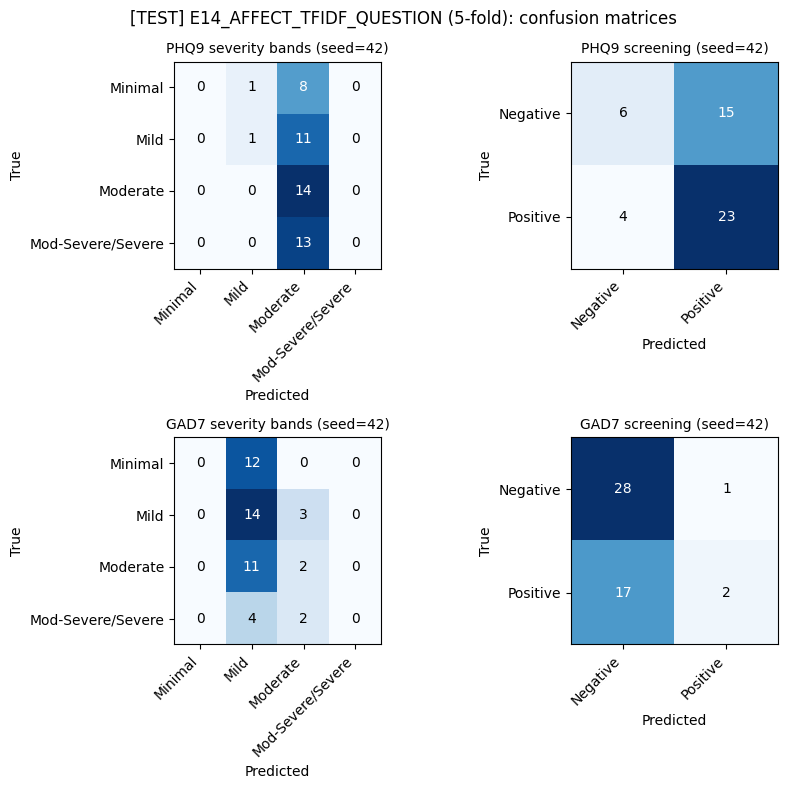

E14_AFFECT_TFIDF_QUESTION seed=42 target=PHQ9 best=RandomForest rmse=5.292 r2=0.072 (14.2s)
E14_AFFECT_TFIDF_QUESTION seed=42 target=GAD7 best=RandomForest rmse=4.848 r2=0.071 (14.1s)
E14_AFFECT_TFIDF_QUESTION: 22 columns, 10-fold, 0.5 min
[TEST] E14_AFFECT_TFIDF_QUESTION (10-fold): metrics on the 48 held-out participants


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.848  5.292  3.982  4.307  0.071  0.072

[CROSS-VALIDATION on training data] RMSE per candidate (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,5.657
RidgeCV,6.023
SVR,6.160


[CROSS-VALIDATION on training data] RMSE per candidate (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,4.715
RidgeCV,4.909
SVR,5.121


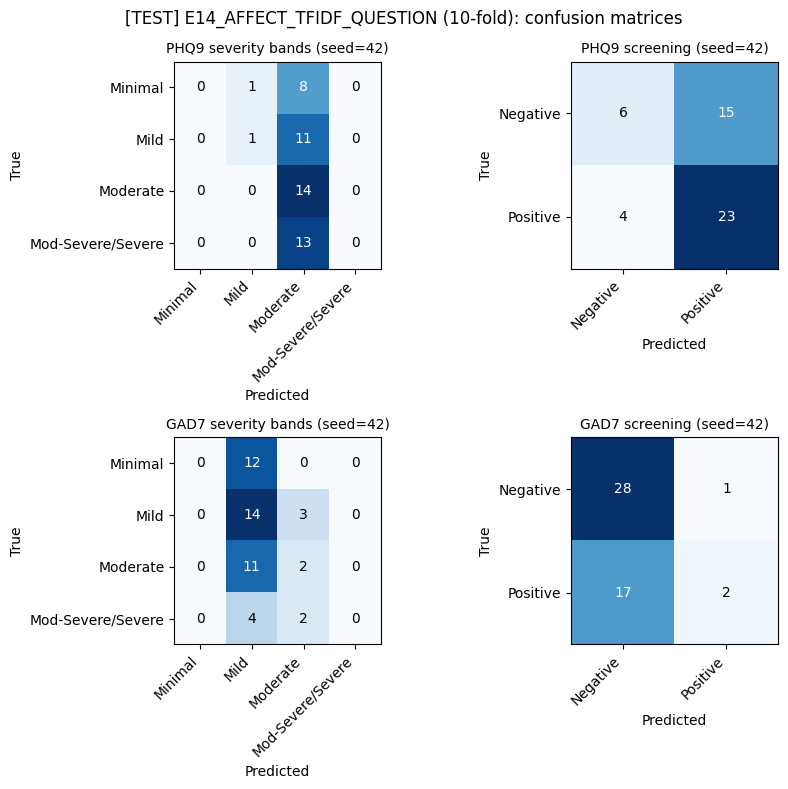

In [36]:
_ = train_and_report(AFFECT_TFIDF_ARM_QUESTION, config.GRANULARITY_QUESTION)

## Stage 6: all three (E15)

Every source at once. Read against E12, E13 and E14: the question is not
whether it is the best number in the table, but whether adding a third source
to any pair does anything.

E15_LEXICAL_AFFECT_TFIDF seed=42 target=PHQ9 best=SVR rmse=5.376 r2=0.043 (6.0s)
E15_LEXICAL_AFFECT_TFIDF seed=42 target=GAD7 best=RandomForest rmse=4.853 r2=0.070 (6.0s)
E15_LEXICAL_AFFECT_TFIDF: 86 columns, 5-fold, 0.2 min
[TEST] E15_LEXICAL_AFFECT_TFIDF (5-fold): metrics on the 48 held-out participants


rmse           mae           r2       
target   GAD7   PHQ9   GAD7   PHQ9  GAD7   PHQ9
seed                                           
42      4.853  5.376  4.017  4.357  0.07  0.043

[CROSS-VALIDATION on training data] RMSE per candidate (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,5.749
RidgeCV,5.965
SVR,5.710


[CROSS-VALIDATION on training data] RMSE per candidate (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,4.670
RidgeCV,5.136
SVR,4.739


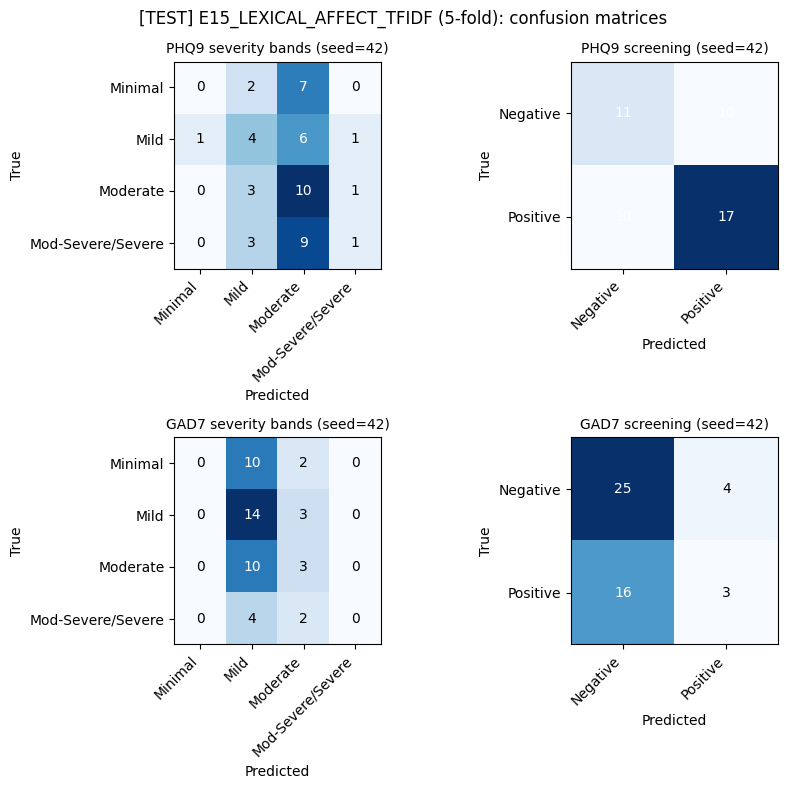

E15_LEXICAL_AFFECT_TFIDF seed=42 target=PHQ9 best=RandomForest rmse=5.306 r2=0.068 (11.1s)
E15_LEXICAL_AFFECT_TFIDF seed=42 target=GAD7 best=SVR rmse=4.991 r2=0.016 (10.8s)
E15_LEXICAL_AFFECT_TFIDF: 86 columns, 10-fold, 0.4 min
[TEST] E15_LEXICAL_AFFECT_TFIDF (10-fold): metrics on the 48 held-out participants


rmse          mae            r2       
target   GAD7   PHQ9  GAD7   PHQ9   GAD7   PHQ9
seed                                           
42      4.991  5.306  3.99  4.364  0.016  0.068

[CROSS-VALIDATION on training data] RMSE per candidate (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,5.735
RidgeCV,5.975
SVR,5.747


[CROSS-VALIDATION on training data] RMSE per candidate (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,4.652
RidgeCV,5.080
SVR,4.609


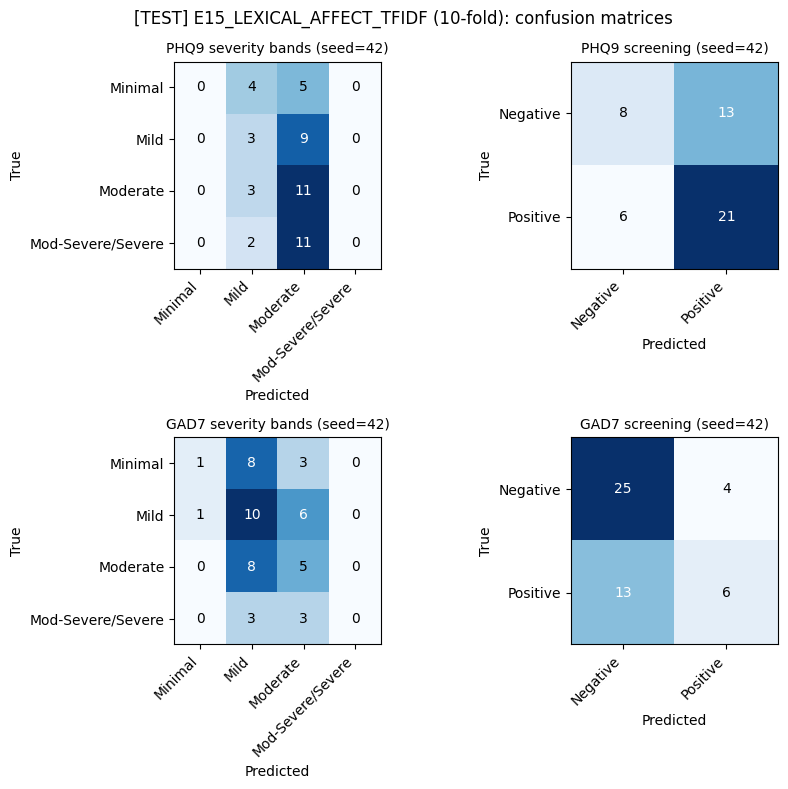

In [37]:
_ = train_and_report(LEXICAL_AFFECT_TFIDF_ARM, config.GRANULARITY_PARTICIPANT)

E15_LEXICAL_AFFECT_TFIDF_QUESTION seed=42 target=PHQ9 best=RandomForest rmse=5.207 r2=0.102 (7.1s)
E15_LEXICAL_AFFECT_TFIDF_QUESTION seed=42 target=GAD7 best=RandomForest rmse=4.851 r2=0.070 (7.1s)
E15_LEXICAL_AFFECT_TFIDF_QUESTION: 73 columns, 5-fold, 0.2 min
[TEST] E15_LEXICAL_AFFECT_TFIDF_QUESTION (5-fold): metrics on the 48 held-out participants


rmse           mae           r2       
target   GAD7   PHQ9   GAD7   PHQ9  GAD7   PHQ9
seed                                           
42      4.851  5.207  4.044  4.236  0.07  0.102

[CROSS-VALIDATION on training data] RMSE per candidate (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,5.810
RidgeCV,5.928
SVR,5.857


[CROSS-VALIDATION on training data] RMSE per candidate (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,4.783
RidgeCV,4.850
SVR,4.952


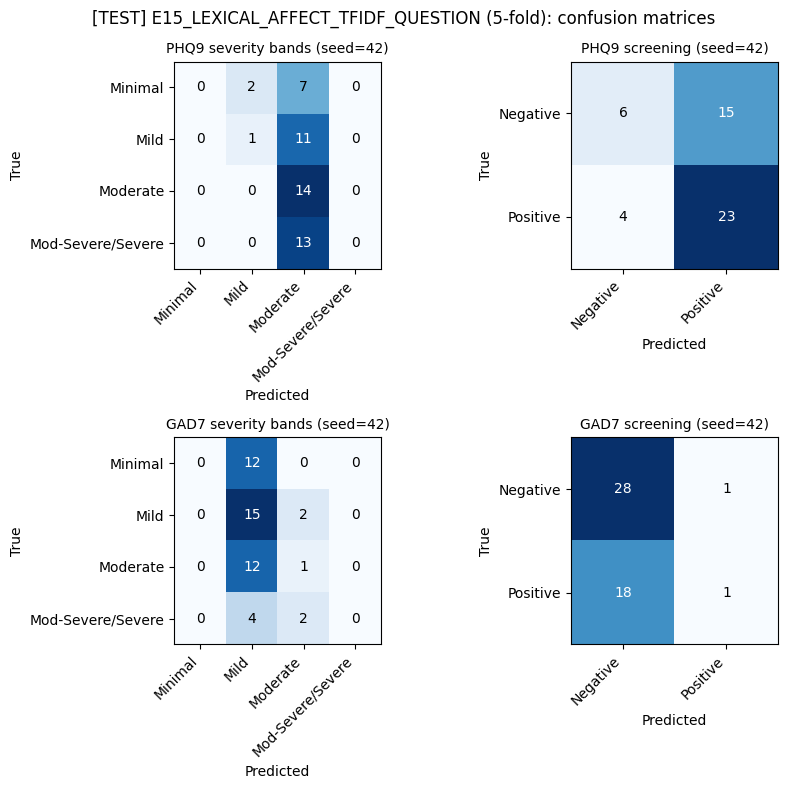

E15_LEXICAL_AFFECT_TFIDF_QUESTION seed=42 target=PHQ9 best=RandomForest rmse=5.207 r2=0.102 (13.1s)
E15_LEXICAL_AFFECT_TFIDF_QUESTION seed=42 target=GAD7 best=RandomForest rmse=4.851 r2=0.070 (12.9s)
E15_LEXICAL_AFFECT_TFIDF_QUESTION: 73 columns, 10-fold, 0.4 min
[TEST] E15_LEXICAL_AFFECT_TFIDF_QUESTION (10-fold): metrics on the 48 held-out participants


rmse           mae           r2       
target   GAD7   PHQ9   GAD7   PHQ9  GAD7   PHQ9
seed                                           
42      4.851  5.207  4.044  4.236  0.07  0.102

[CROSS-VALIDATION on training data] RMSE per candidate (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,5.700
RidgeCV,5.826
SVR,5.756


[CROSS-VALIDATION on training data] RMSE per candidate (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
RandomForest,4.735
RidgeCV,4.788
SVR,4.848


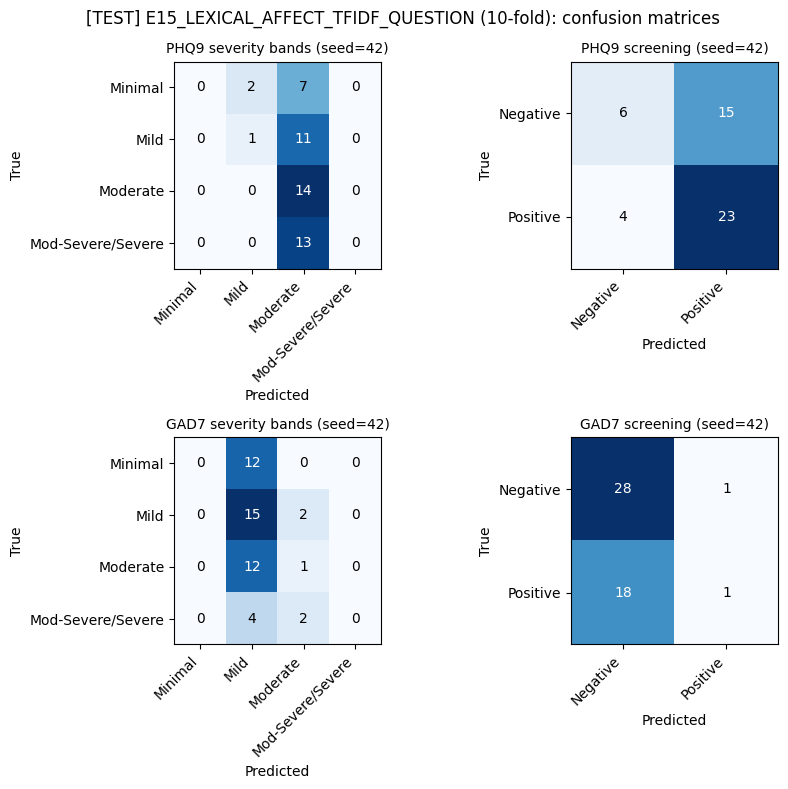

In [38]:
_ = train_and_report(LEXICAL_AFFECT_TFIDF_ARM_QUESTION, config.GRANULARITY_QUESTION)

## Is any of this better than predicting the mean?

With a small training set, the difference between "slightly better than the
mean" and "no better than the mean" is often the finding, so the mean
predictor is scored beside the real models. It is never selected as an arm's
answer.

Shown at both fold counts. Where 5 and 10 folds pick different regressors for
the same arm, that choice rests on the fold estimate rather than on the
features — worth knowing before quoting any of these numbers.

Participant level only. Question-level cross-validation scores individual
answers while the test metric aggregates to participants, so the two are not
on the same scale.

In [39]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from src.regression_models import BASELINE_KEY, RIDGE_ALPHAS, build_regressors, make_pipeline

rows = []
for n_splits in CV_SPLITS:
    run_cfg = replace(cfg, n_cv_splits=n_splits)
    cv_folds = list(splits.cv_splitter(n_splits=n_splits, random_state=cfg.seeds[0])
                    .split(np.zeros(len(train_frame)), splits.stratify_key(train_frame)))
    for arm in PARTICIPANT_ARMS:
        X_all, preprocessor = encoder_data(arm, combined, docs_all,
                                           participant_features, run_cfg)
        X = X_all.loc[train_frame.index]
        for target in TARGETS:
            y = train_frame[config.TARGET_COLUMNS[target]].to_numpy()
            for name, reg in build_regressors(cfg.seeds[0], cfg.regressors).items():
                scores = cross_val_score(make_pipeline(reg, preprocessor), X, y,
                                         cv=cv_folds,
                                         scoring="neg_root_mean_squared_error")
                rows.append({"folds": n_splits, "arm": arm, "target": target,
                             "model": name, "cv_rmse": -float(np.mean(scores))})

baseline = pd.DataFrame(rows)
for n_splits in CV_SPLITS:
    print(f"[CROSS-VALIDATION on training data, {n_splits}-fold] "
          f"RMSE per arm and regressor, lower is better.")
    display(baseline[baseline.folds == n_splits]
            .pivot_table(index="model", columns=["target", "arm"],
                         values="cv_rmse", sort=False).round(3))

best = (baseline[baseline.model != BASELINE_KEY]
        .loc[lambda d: d.groupby(["folds", "arm", "target"]).cv_rmse.idxmin()])
dummy = baseline[baseline.model == BASELINE_KEY].set_index(
    ["folds", "arm", "target"]).cv_rmse
best = best.assign(dummy=best.set_index(["folds", "arm", "target"]).index.map(dummy))
best["gain_over_mean"] = best["dummy"] - best["cv_rmse"]
print("Best model per arm and fold count, and how far it beats the mean "
      "predictor (questionnaire points). Where the two fold counts pick "
      "different models, the choice is resting on the fold estimate rather "
      "than on the features.")
display(best.pivot(index=["arm", "folds"], columns="target",
                   values=["model", "cv_rmse", "gain_over_mean"]))

[CROSS-VALIDATION on training data, 5-fold] RMSE per arm and regressor, lower is better.


target,PHQ9,GAD7,PHQ9,GAD7,PHQ9,GAD7,PHQ9,GAD7,PHQ9,GAD7,PHQ9,GAD7
arm,E10_LEXICAL,E10_LEXICAL,E11_AFFECT,E11_AFFECT,E12_LEXICAL_AFFECT,E12_LEXICAL_AFFECT,E13_LEXICAL_TFIDF,E13_LEXICAL_TFIDF,E14_AFFECT_TFIDF,E14_AFFECT_TFIDF,E15_LEXICAL_AFFECT_TFIDF,E15_LEXICAL_AFFECT_TFIDF
model,,,,,,,,,,,,
SVR,5.733,4.754,6.442,5.210,5.712,4.744,5.728,4.754,6.387,5.182,5.710,4.739
RandomForest,5.920,4.738,5.905,4.787,5.761,4.686,5.848,4.733,5.669,4.636,5.749,4.670
RidgeCV,5.747,4.847,5.853,4.655,5.964,5.134,5.866,4.730,5.890,4.655,5.965,5.136
Dummy(mean),5.942,4.945,5.942,4.945,5.942,4.945,5.942,4.945,5.942,4.945,5.942,4.945


[CROSS-VALIDATION on training data, 10-fold] RMSE per arm and regressor, lower is better.


target,PHQ9,GAD7,PHQ9,GAD7,PHQ9,GAD7,PHQ9,GAD7,PHQ9,GAD7,PHQ9,GAD7
arm,E10_LEXICAL,E10_LEXICAL,E11_AFFECT,E11_AFFECT,E12_LEXICAL_AFFECT,E12_LEXICAL_AFFECT,E13_LEXICAL_TFIDF,E13_LEXICAL_TFIDF,E14_AFFECT_TFIDF,E14_AFFECT_TFIDF,E15_LEXICAL_AFFECT_TFIDF,E15_LEXICAL_AFFECT_TFIDF
model,,,,,,,,,,,,
SVR,5.773,4.647,6.246,4.916,5.751,4.615,5.764,4.645,6.200,4.897,5.747,4.609
RandomForest,5.898,4.801,5.812,4.792,5.743,4.694,5.762,4.725,5.711,4.590,5.735,4.652
RidgeCV,5.825,5.067,5.778,4.610,5.995,5.081,5.826,5.071,5.777,4.609,5.975,5.080
Dummy(mean),5.941,4.927,5.941,4.927,5.941,4.927,5.941,4.927,5.941,4.927,5.941,4.927


Best model per arm and fold count, and how far it beats the mean predictor (questionnaire points). Where the two fold counts pick different models, the choice is resting on the fold estimate rather than on the features.


model                 cv_rmse  \
target                                  GAD7          PHQ9      GAD7   
arm                      folds                                         
E10_LEXICAL              5      RandomForest           SVR  4.737573   
                         10              SVR           SVR  4.647307   
E11_AFFECT               5           RidgeCV       RidgeCV  4.655053   
                         10          RidgeCV       RidgeCV  4.609525   
E12_LEXICAL_AFFECT       5      RandomForest           SVR  4.686028   
                         10              SVR  RandomForest  4.614784   
E13_LEXICAL_TFIDF        5           RidgeCV           SVR   4.72981   
                         10              SVR  RandomForest  4.644807   
E14_AFFECT_TFIDF         5      RandomForest  RandomForest  4.635837   
                         10     RandomForest  RandomForest  4.590061   
E15_LEXICAL_AFFECT_TFIDF 5      RandomForest           SVR  4.670202   
                         10              SVR  RandomForest  4.609308   

                                         gain_over_mean            
target                              PHQ9           GAD7      PHQ9  
arm                      folds                                     
E10_LEXICAL              5      5.733463       0.207387  0.208741  
                         10     5.772621       0.279782  0.168657  
E11_AFFECT               5      5.852727       0.289908  0.089477  
                         10     5.777827       0.317564  0.163451  
E12_LEXICAL_AFFECT       5       5.71218       0.258933  0.230024  
                         10     5.743311       0.312305  0.197967  
E13_LEXICAL_TFIDF        5      5.728268       0.215151  0.213936  
                         10     5.761976       0.282282  0.179302  
E14_AFFECT_TFIDF         5      5.669021       0.309124  0.273184  
                         10     5.710609       0.337029  0.230669  
E15_LEXICAL_AFFECT_TFIDF 5      5.710148       0.274759  0.232056  
                         10     5.735341       0.317781  0.205937

## The ablation

Every arm is scored on the same participants, so each contrast is paired on
per-participant error rather than being a difference of two RMSEs. Each gets a
bootstrap confidence interval and a Wilcoxon signed-rank test
(`PROTOCOL.md` Section 10).

The contrasts are factorial: each asks what one source adds to a fixed
background, and each source is asked about more than once so no answer rests
on a single pairing.

| Adding | Contrasts |
|---|---|
| affect | E10 vs E12, E13 vs E15 |
| TF-IDF | E10 vs E13, E11 vs E14, E12 vs E15 |
| lexical | E11 vs E12, E14 vs E15 |

Holm-Bonferroni is applied within each fold count, granularity and target —
one family of comparisons is one outcome, on one set of people, under one
selection procedure. A negative squared-error difference favours the second
arm of the pair.

In [40]:
CONTRASTS = [
    (LEXICAL_ARM, LEXICAL_AFFECT_ARM, "+affect on lexical"),
    (LEXICAL_TFIDF_ARM, LEXICAL_AFFECT_TFIDF_ARM, "+affect on lexical+tfidf"),
    (LEXICAL_ARM, LEXICAL_TFIDF_ARM, "+tfidf on lexical"),
    (AFFECT_ARM, AFFECT_TFIDF_ARM, "+tfidf on affect"),
    (LEXICAL_AFFECT_ARM, LEXICAL_AFFECT_TFIDF_ARM, "+tfidf on lexical+affect"),
    (AFFECT_ARM, LEXICAL_AFFECT_ARM, "+lexical on affect"),
    (AFFECT_TFIDF_ARM, LEXICAL_AFFECT_TFIDF_ARM, "+lexical on affect+tfidf"),
]

all_predictions = logging_utils.load_predictions()
all_predictions = all_predictions[
    (all_predictions.augmentation == cfg.augmentation)
    & (all_predictions.family == config.FAMILY_LEXICAL)]

rows = []
for n_splits in CV_SPLITS:
  # Holm is applied within one fold count, one granularity and one target:
  # runs under different fold counts are different selection procedures and
  # do not belong to the same family of comparisons.
  predictions = all_predictions[
      all_predictions.search == search_label(replace(cfg, n_cv_splits=n_splits))]
  for granularity, suffix in [(config.GRANULARITY_PARTICIPANT, ""),
                            (config.GRANULARITY_QUESTION, "_QUESTION")]:
    for target in TARGETS:
        family = {}
        family_rows = []
        for arm_a, arm_b, question in CONTRASTS:
            a, b = (predictions[(predictions.encoder == arm + suffix)
                                & (predictions.target == target)
                                & (predictions.granularity == granularity)]
                    .set_index("participant") for arm in (arm_a, arm_b))
            shared = a.index.intersection(b.index)
            if len(shared) == 0:
                print(f"missing pair: {granularity} {target} {question}")
                continue
            result = metrics.paired_comparison(a.loc[shared, "y_true"].to_numpy(),
                                               a.loc[shared, "y_pred"].to_numpy(),
                                               b.loc[shared, "y_pred"].to_numpy())
            family[question] = result["squared_error_wilcoxon_p"]
            low, high = result["squared_error_diff_ci95"]
            family_rows.append({"folds": n_splits, "granularity": granularity,
                                "target": target,
                                "contrast": question, "n": len(shared),
                                "sq_err_diff": result["squared_error_diff_mean"],
                                "ci95_low": low, "ci95_high": high,
                                "wilcoxon_p": family[question]})
        # Holm within this granularity and target, not across the whole table.
        holm = metrics.holm_bonferroni(family)
        for row in family_rows:
            row["holm_alpha"] = holm[row["contrast"]]["adjusted_alpha"]
            row["significant"] = holm[row["contrast"]]["significant"]
        rows += family_rows

ablation = pd.DataFrame(rows)
print(f"[TEST] paired on the {N_TEST} held-out participants. A negative "
      f"difference favours the second arm of the contrast.")
display(ablation.round(3))

[TEST] paired on the 48 held-out participants. A negative difference favours the second arm of the contrast.


,folds,granularity,target,contrast,n,sq_err_diff,ci95_low,ci95_high,wilcoxon_p,holm_alpha,significant
0,5,participant,PHQ9,+affect on lexical,48,5.026,-0.712,10.836,0.050,0.008,False
1,5,participant,PHQ9,+affect on lexical+tfidf,48,4.889,-0.788,10.578,0.057,0.010,False
2,5,participant,PHQ9,+tfidf on lexical,48,0.235,0.066,0.420,0.012,0.007,False
3,5,participant,PHQ9,+tfidf on affect,48,0.503,-2.553,3.793,0.566,0.017,False
4,5,participant,PHQ9,+tfidf on lexical+affect,48,0.098,0.004,0.201,0.078,0.012,False
5,5,participant,PHQ9,+lexical on affect,48,0.446,-6.093,7.171,0.696,0.025,False
6,5,participant,PHQ9,+lexical on affect+tfidf,48,0.041,-6.394,5.847,0.819,0.050,False
7,5,participant,GAD7,+affect on lexical,48,-0.520,-3.521,2.410,0.907,0.050,False
8,5,participant,GAD7,+affect on lexical+tfidf,48,3.395,-2.629,9.811,0.608,0.017,False
9,5,participant,GAD7,+tfidf on lexical,48,-3.604,-9.380,1.762,0.479,0.012,False


## What the features say

The reason these arms exist: unlike an embedding, every column has a name.
Coefficients are over standardized features and fitted on the training
participants only — reading importances off the held-out set would spend it on
something other than the measurement it is reserved for.

Only the arms without TF-IDF are shown. With the vectorizer in the pipeline
the coefficients run over vocabulary too, and a chart of mostly-zero weights
says less than a table of named ones.

Collinear groups (`results/diagnostics/lexical/*/collinearity.csv`) should be
read together rather than ranked within: a penalized model spreads weight
across correlated columns according to the penalty, not to which one matters.

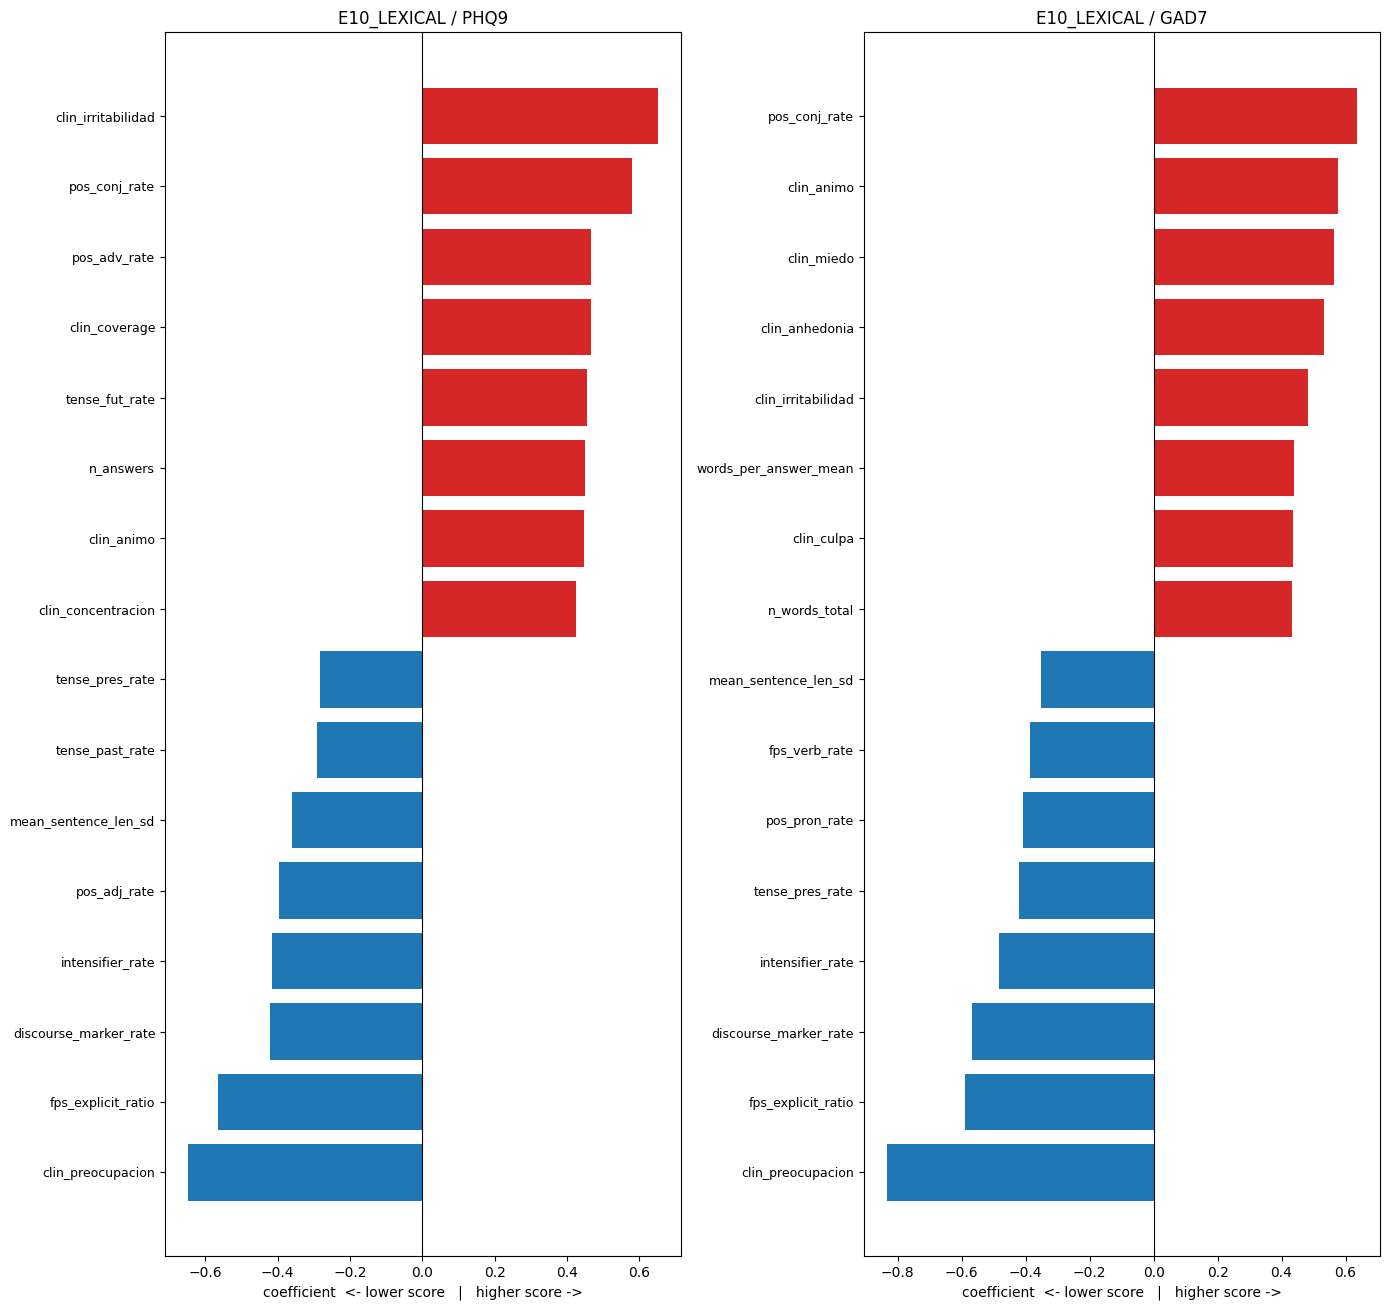

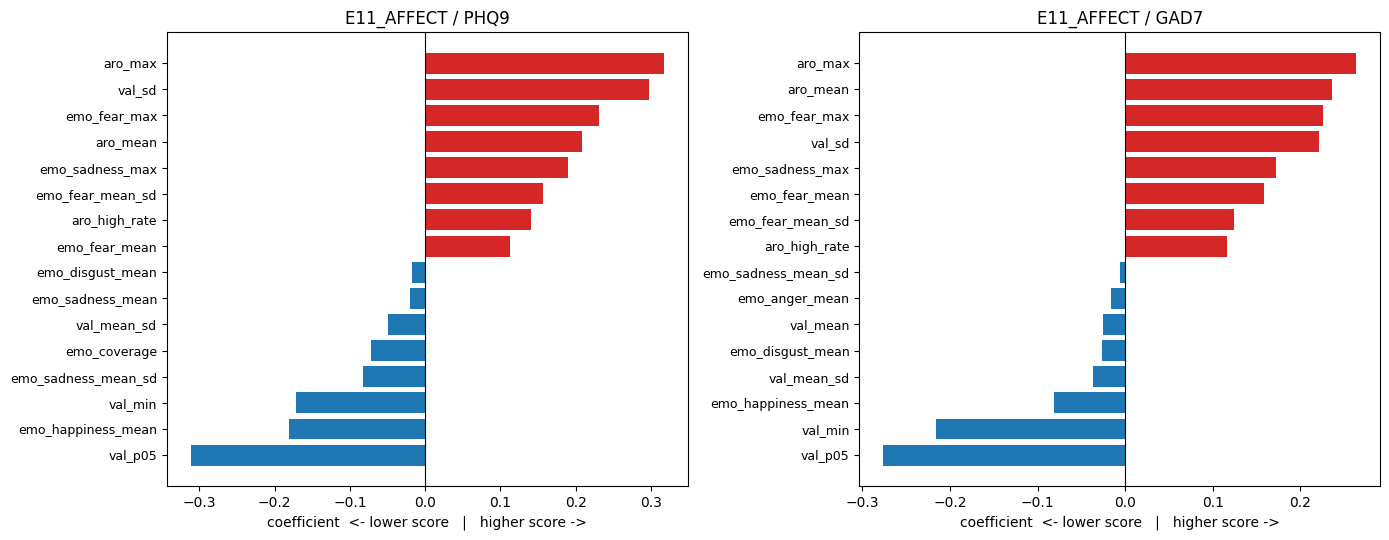

In [41]:
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import Pipeline

TOP_N = 16
for arm in (LEXICAL_ARM, AFFECT_ARM):
    X = participant_features[arm].loc[train_frame.index]
    fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(X.columns) * 0.22)))
    for ax, target in zip(axes, TARGETS):
        y = train_frame[config.TARGET_COLUMNS[target]].to_numpy()
        model = Pipeline([("scale", StandardScaler()),
                          ("reg", RidgeCV(alphas=RIDGE_ALPHAS))]).fit(X, y)
        coefficients = pd.Series(model.named_steps["reg"].coef_,
                                 index=X.columns).sort_values()
        shown = (coefficients if len(coefficients) <= TOP_N else
                 pd.concat([coefficients.head(TOP_N // 2), coefficients.tail(TOP_N // 2)]))
        ax.barh(range(len(shown)), shown.to_numpy(),
                color=["tab:red" if v > 0 else "tab:blue" for v in shown])
        ax.set_yticks(range(len(shown)), shown.index, fontsize=9)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_title(f"{arm} / {target}")
        ax.set_xlabel("coefficient  <- lower score   |   higher score ->")
    plt.tight_layout()
    plt.show()

## Summary

The arms of this notebook, on the held-out participants.

Restricted to these arms on purpose: the rest of the study used a wider set of
candidate regressors, so one table would rank runs produced by different
selection procedures. The same applies between the two fold counts inside this
table, which is why they are rows rather than an average.

Every arm is a single run at one seed, so none of these orderings can be read
against the noise of the procedure that produced it (`PROTOCOL.md` Sections 10
and 13).

In [42]:
log = logging_utils.load_all_runs()
log = log[(log.augmentation == cfg.augmentation) & log.encoder.isin(NOTEBOOK_ARMS)]

# The fold count lives in the `search` field, which is what keeps a 5-fold and
# a 10-fold run of one arm from colliding on a single key.
LABELS = {search_label(replace(cfg, n_cv_splits=k)): k for k in CV_SPLITS}
log = log[log.search.isin(LABELS)].assign(folds=log.search.map(LABELS))

for target in TARGETS:
    print(f"[TEST] {target}, sorted by RMSE (lower is better). "
          f"R2 = 0 means no better than predicting the training mean.")
    display(log[log.target == target]
            .set_index(["granularity", "encoder", "folds"])
            [["rmse", "mae", "r2", "selected_model"]]
            .sort_values("rmse").round(3))

print("[TEST] the two fold counts side by side. The features and the hold-out "
      "split are identical across a pair, so any gap is the selection "
      "procedure alone.")
display(log.pivot_table(index=["granularity", "encoder"], columns=["target", "folds"],
                        values="rmse").round(3))

[TEST] PHQ9, sorted by RMSE (lower is better). R2 = 0 means no better than predicting the training mean.


rmse    mae     r2  \
granularity encoder                           folds                        
participant E12_LEXICAL_AFFECT                10     5.166  4.245  0.116   
question    E13_LEXICAL_TFIDF_QUESTION        10     5.197  4.197  0.105   
                                              5      5.197  4.197  0.105   
            E15_LEXICAL_AFFECT_TFIDF_QUESTION 5      5.207  4.236  0.102   
                                              10     5.207  4.236  0.102   
            E12_LEXICAL_AFFECT_QUESTION       10     5.216  4.294  0.099   
            E14_AFFECT_TFIDF_QUESTION         10     5.292  4.307  0.072   
                                              5      5.292  4.307  0.072   
participant E15_LEXICAL_AFFECT_TFIDF          10     5.306  4.364  0.068   
            E13_LEXICAL_TFIDF                 10     5.318  4.378  0.063   
question    E10_LEXICAL_QUESTION              10     5.338  4.348  0.056   
                                              5      5.338  4.348  0.056   
participant E15_LEXICAL_AFFECT_TFIDF          5      5.376  4.357  0.043   
            E14_AFFECT_TFIDF                  10     5.380  4.389  0.041   
                                              5      5.380  4.389  0.041   
            E12_LEXICAL_AFFECT                5      5.385  4.362  0.039   
question    E11_AFFECT_QUESTION               5      5.420  4.447  0.027   
                                              10     5.420  4.447  0.027   
participant E11_AFFECT                        10     5.427  4.477  0.025   
                                              5      5.427  4.477  0.025   
question    E12_LEXICAL_AFFECT_QUESTION       5      5.461  4.585  0.012   
participant E13_LEXICAL_TFIDF                 5      5.813  4.875 -0.119   
            E10_LEXICAL                       5      5.833  4.895 -0.127   
                                              10     5.833  4.895 -0.127   

                                                    selected_model  
granularity encoder                           folds                 
participant E12_LEXICAL_AFFECT                10      RandomForest  
question    E13_LEXICAL_TFIDF_QUESTION        10      RandomForest  
                                              5       RandomForest  
            E15_LEXICAL_AFFECT_TFIDF_QUESTION 5       RandomForest  
                                              10      RandomForest  
            E12_LEXICAL_AFFECT_QUESTION       10      RandomForest  
            E14_AFFECT_TFIDF_QUESTION         10      RandomForest  
                                              5       RandomForest  
participant E15_LEXICAL_AFFECT_TFIDF          10      RandomForest  
            E13_LEXICAL_TFIDF                 10      RandomForest  
question    E10_LEXICAL_QUESTION              10      RandomForest  
                                              5       RandomForest  
participant E15_LEXICAL_AFFECT_TFIDF          5                SVR  
            E14_AFFECT_TFIDF                  10      RandomForest  
                                              5       RandomForest  
            E12_LEXICAL_AFFECT                5                SVR  
question    E11_AFFECT_QUESTION               5            RidgeCV  
                                              10           RidgeCV  
participant E11_AFFECT                        10           RidgeCV  
                                              5            RidgeCV  
question    E12_LEXICAL_AFFECT_QUESTION       5                SVR  
participant E13_LEXICAL_TFIDF                 5                SVR  
            E10_LEXICAL                       5                SVR  
                                              10               SVR

[TEST] GAD7, sorted by RMSE (lower is better). R2 = 0 means no better than predicting the training mean.


rmse    mae     r2  \
granularity encoder                           folds                        
question    E13_LEXICAL_TFIDF_QUESTION        5      4.816  4.005  0.084   
                                              10     4.816  4.005  0.084   
participant E10_LEXICAL                       5      4.831  3.998  0.078   
question    E12_LEXICAL_AFFECT_QUESTION       10     4.847  4.021  0.072   
                                              5      4.847  4.021  0.072   
            E14_AFFECT_TFIDF_QUESTION         5      4.848  3.982  0.071   
                                              10     4.848  3.982  0.071   
            E15_LEXICAL_AFFECT_TFIDF_QUESTION 5      4.851  4.044  0.070   
                                              10     4.851  4.044  0.070   
participant E15_LEXICAL_AFFECT_TFIDF          5      4.853  4.017  0.070   
question    E10_LEXICAL_QUESTION              5      4.868  4.058  0.064   
participant E12_LEXICAL_AFFECT                5      4.885  3.967  0.057   
            E14_AFFECT_TFIDF                  5      4.955  4.087  0.030   
                                              10     4.955  4.087  0.030   
question    E11_AFFECT_QUESTION               10     4.966  4.112  0.026   
                                              5      4.984  4.117  0.019   
participant E15_LEXICAL_AFFECT_TFIDF          10     4.991  3.990  0.016   
            E12_LEXICAL_AFFECT                10     4.995  3.991  0.014   
question    E10_LEXICAL_QUESTION              10     4.997  4.231  0.013   
participant E11_AFFECT                        5      5.087  4.155 -0.022   
                                              10     5.087  4.155 -0.022   
            E13_LEXICAL_TFIDF                 10     5.171  4.318 -0.056   
            E10_LEXICAL                       10     5.186  4.327 -0.062   
            E13_LEXICAL_TFIDF                 5      5.191  4.255 -0.064   

                                                    selected_model  
granularity encoder                           folds                 
question    E13_LEXICAL_TFIDF_QUESTION        5       RandomForest  
                                              10      RandomForest  
participant E10_LEXICAL                       5       RandomForest  
question    E12_LEXICAL_AFFECT_QUESTION       10           RidgeCV  
                                              5            RidgeCV  
            E14_AFFECT_TFIDF_QUESTION         5       RandomForest  
                                              10      RandomForest  
            E15_LEXICAL_AFFECT_TFIDF_QUESTION 5       RandomForest  
                                              10      RandomForest  
participant E15_LEXICAL_AFFECT_TFIDF          5       RandomForest  
question    E10_LEXICAL_QUESTION              5            RidgeCV  
participant E12_LEXICAL_AFFECT                5       RandomForest  
            E14_AFFECT_TFIDF                  5       RandomForest  
                                              10      RandomForest  
question    E11_AFFECT_QUESTION               10      RandomForest  
                                              5            RidgeCV  
participant E15_LEXICAL_AFFECT_TFIDF          10               SVR  
            E12_LEXICAL_AFFECT                10               SVR  
question    E10_LEXICAL_QUESTION              10               SVR  
participant E11_AFFECT                        5            RidgeCV  
                                              10           RidgeCV  
            E13_LEXICAL_TFIDF                 10               SVR  
            E10_LEXICAL                       10               SVR  
            E13_LEXICAL_TFIDF                 5            RidgeCV

[TEST] the two fold counts side by side. The features and the hold-out split are identical across a pair, so any gap is the selection procedure alone.


target                                          GAD7          PHQ9       
folds                                             5      10     5      10
granularity encoder                                                      
participant E10_LEXICAL                        4.831  5.186  5.833  5.833
            E11_AFFECT                         5.087  5.087  5.427  5.427
            E12_LEXICAL_AFFECT                 4.885  4.995  5.385  5.166
            E13_LEXICAL_TFIDF                  5.191  5.171  5.813  5.318
            E14_AFFECT_TFIDF                   4.955  4.955  5.380  5.380
            E15_LEXICAL_AFFECT_TFIDF           4.853  4.991  5.376  5.306
question    E10_LEXICAL_QUESTION               4.868  4.997  5.338  5.338
            E11_AFFECT_QUESTION                4.984  4.966  5.420  5.420
            E12_LEXICAL_AFFECT_QUESTION        4.847  4.847  5.461  5.216
            E13_LEXICAL_TFIDF_QUESTION         4.816  4.816  5.197  5.197
            E14_AFFECT_TFIDF_QUESTION          4.848  4.848  5.292  5.292
            E15_LEXICAL_AFFECT_TFIDF_QUESTION  4.851  4.851  5.207  5.207